# 1. Project Goal

## Business Context & Problem
A Portuguese banking institution conducted direct marketing campaigns based on phone calls. Frequently, more than one contact to the same client was necessary to assess whether the product (bank term deposit) would be subscribed.

The business problem is to **predict whether a bank customer will subscribe to a term deposit**.

- **Target Variable**: `y`
- **Values**: `yes` / `no`
- **Machine Learning Task**: Binary Classification

---

## Project Goal
The focus of this project is **not model complexity**.

The goal is to understand how **data preparation** affects the quality and realism of a machine learning model.

Topics that are explored throughout this project:
- **duplicates**
- **missing and unknown values**
- **outliers**
- **data leakage**
- **scaling**
- **categorical encoding**
- **class imbalance**
- **feature creation**
- **feature selection**
- **permutation importance**

---

## Roadmap & Current Progress
1. **Step 1**: Project Setup, Dataset Loading, & Data Quality Audit *(Completed)*
2. **Step 2**: Feature/Target Separation, Data Leakage Removal, Stratified Split, & Missing Imputation *(Completed)*
3. **Step 3**: Outlier Inspection and Feature Scaling *(Completed)*
4. **Step 4**: Categorical Encoding *(Completed)*
5. **Step 5**: Feature Creation and Discretization *(Current Step)*

> **Strict Constraints**:
> - **DO NOT train a machine learning model yet.**
> - **DO NOT balance the target yet.**
> - **DO NOT perform feature selection yet.**

In [1]:
import io
import urllib.request
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, MinMaxScaler

# Display formatting options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# 2. Load Dataset

We load the official Bank Marketing dataset from the **UCI Machine Learning Repository**.

We use the main `bank-full.csv` dataset, which contains approximately 45,211 rows and includes the target column `y`.

In [2]:
# Download and load bank-full.csv directly from official UCI archive
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

req = urllib.request.Request(url, headers=headers)
with urllib.request.urlopen(req) as response:
    zip_bytes = io.BytesIO(response.read())

with zipfile.ZipFile(zip_bytes) as archive:
    with archive.open("bank-full.csv") as csv_file:
        df = pd.read_csv(csv_file, sep=";")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())
print("\nColumn Names:")
print(list(df.columns))

Dataset Shape: (45211, 17)

First 5 Rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


### Observations on Dataset Loading
- The dataset successfully loaded with **45,211 rows** and **17 columns**, matching the benchmark UCI `bank-full` specification.
- The target column `y` is present.
- The 17 columns capture demographic attributes (such as `age`, `job`, `marital`, `education`, `balance`, `housing`, `loan`) and campaign contact history (such as `contact`, `day`, `month`, `duration`, `campaign`, `pdays`, `previous`, `poutcome`).

# 3. Understand the Dataset

Before performing any transformations, we inspect data types, feature representations, summary statistics, and categorical cardinality.

In [3]:
# Display structural information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


### Observations on df.info()
- The dataset has 17 columns and 45,211 entries.
- All columns currently show 45,211 non-null entries under standard null checks.
- Types consist of 7 integer features and 10 string/object features.

In [4]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [col for col in df.columns if col not in numerical_cols]

print(f"Numerical Columns ({len(numerical_cols)}):")
print(numerical_cols)

print(f"\nCategorical Columns ({len(categorical_cols)}):")
print(categorical_cols)

Numerical Columns (7):
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Columns (10):
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


### Feature Categorization
- **Numerical columns (7)**: `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`
- **Categorical columns (10)**: `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`, `y`

In [5]:
# Basic numerical statistics
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Observations on Basic Numerical Statistics
- `age`: Ranges from 18 to 95 years, with a median of 39.0 and mean of ~40.9 years.
- `balance`: Mean is 1,362.27, while the median is only 448.0, with values ranging from -8,019 to 102,127, indicating heavy positive skewness.
- `duration`: Call duration averages 258.16 seconds (~4.3 minutes), with median 180 seconds, maxing at 4,918 seconds (~82 minutes).
- `campaign`: Number of contacts during this campaign averages 2.76, median 2.0, with a maximum of 63.
- `pdays`: Median is -1.0 (over 75% of rows are -1.0, representing clients not previously contacted).
- `previous`: Median is 0.0, max is 275 contacts prior to this campaign.

In [6]:
# Display number of unique values per categorical column
unique_counts = df[categorical_cols].nunique()
print("Number of Unique Values per Categorical Column:")
print(unique_counts)

Number of Unique Values per Categorical Column:
job          12
marital       3
education     4
default       2
housing       2
loan          2
contact       3
month        12
poutcome      4
y             2
dtype: int64


### Observations on Categorical Columns
- **Binary Features (2 unique values)**: `default`, `housing`, `loan`, and target `y` (`yes` / `no`).
- **Low to Moderate Cardinality (3–4 unique values)**: `marital` (3 values), `education` (4 values), `contact` (3 values), `poutcome` (4 values).
- **Higher Cardinality (12 unique values)**: `job` (12 categories), `month` (12 months).
- **Important**: No categorical encoding has been applied yet.

# 4. Data Quality Audit

We perform inspection only. We do **NOT** modify the dataset, drop rows, or impute values in this step.

### Duplicates

In [7]:
# Check for duplicate rows
print("Duplicate rows count:", df.duplicated().sum())

Duplicate rows count: 0


### Observations on Duplicates
- `df.duplicated().sum()` returns **0**.
- There are no duplicate rows in the raw dataset. We do not drop any duplicates.

### Missing Values

In [8]:
# Check for standard missing values (NaN)
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing (NaN) values:", df.isnull().sum().sum())

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total missing (NaN) values: 0


### Observations on Missing Values
- Total missing (`NaN`) values across the entire dataset is **0**.
- Standard missing value checks do not reveal any explicit null entries.

### "Unknown" Categories

In [9]:
# Inspect all categorical columns for placeholder "unknown" entries
unknown_records = []
for col in categorical_cols:
    count = (df[col] == "unknown").sum()
    pct = (count / len(df)) * 100
    unknown_records.append({
        "column": col,
        "unknown_count": count,
        "unknown_percentage": round(pct, 2)
    })

unknown_df = pd.DataFrame(unknown_records).sort_values(by="unknown_percentage", ascending=False).reset_index(drop=True)
print("Unknown Values per Categorical Column:")
display(unknown_df)

Unknown Values per Categorical Column:


,column,unknown_count,unknown_percentage
0,poutcome,36959,81.75
1,contact,13020,28.80
2,education,1857,4.11
3,job,288,0.64
4,marital,0,0.00
5,default,0,0.00
6,loan,0,0.00
7,housing,0,0.00
8,month,0,0.00
9,y,0,0.00


### Explanation of "Unknown" Categories

Missing information is not always represented as NaN. In real datasets, placeholder categories such as "unknown" may also require investigation.

#### Key Findings from the "Unknown" Audit:
1. **`poutcome` (36,959 rows / 81.75%)**: The outcome of the previous marketing campaign is overwhelmingly "unknown". This is because the vast majority of clients were never contacted in prior campaigns.
2. **`contact` (13,020 rows / 28.80%)**: The communication contact type (cellular vs. telephone) is unknown for nearly 29% of clients.
3. **`education` (1,857 rows / 4.11%)**: The customer's education level was not captured for 4.11% of individuals.
4. **`job` (288 rows / 0.64%)**: Job type is unknown for 288 clients.
5. **Other categorical columns** (`marital`, `default`, `housing`, `loan`, `month`, `y`): Contain **0%** unknown values.

> **Important**: We do **NOT** replace "unknown" with NaN yet. We will address strategies for handling "unknown" in Section 8.

### Potential Outlier Inspection

In [10]:
# Print min, max, median, and mean for each numerical feature
outlier_summary = pd.DataFrame({
    "min": df[numerical_cols].min(),
    "max": df[numerical_cols].max(),
    "median": df[numerical_cols].median(),
    "mean": df[numerical_cols].mean()
})

print("Numerical Feature Statistics for Potential Outlier Inspection:")
display(outlier_summary)

Numerical Feature Statistics for Potential Outlier Inspection:


,min,max,median,mean
age,18,95,39.0,40.936210
balance,-8019,102127,448.0,1362.272058
day,1,31,16.0,15.806419
duration,0,4918,180.0,258.163080
campaign,1,63,2.0,2.763841
pdays,-1,871,-1.0,40.197828
previous,0,275,0.0,0.580323


### Observations on Potential Outliers

We inspect numerical features for strong skewness and unusually extreme values:

- **`balance`**: Min is **-8,019**, Max is **102,127**, Median is **448.0**, and Mean is **1,362.27**. Negative values represent account overdrafts, while the maximum of 102,127 is vastly higher than the 75th percentile. These represent **potential outliers**.
- **`duration`**: Min is **0**, Max is **4,918** (~82 minutes), Median is **180.0** (3 minutes), and Mean is **258.16**. Very long phone calls represent **potential outliers**.
- **`campaign`**: Min is **1**, Max is **63**, Median is **2.0**, and Mean is **2.76**. Clients contacted 30 to 63 times are **potential outliers**.
- **`pdays`**: Min is **-1**, Max is **871**, Median is **-1.0**, and Mean is **40.20**. The value -1 encodes "client was not previously contacted", so extreme positive values (up to 871 days) are **potential outliers** in contact lag.
- **`previous`**: Min is **0**, Max is **275**, Median is **0.0**, and Mean is **0.58**. A maximum of 275 previous contacts is an extreme **potential outlier**.
- **`age`**: Min is **18**, Max is **95**, Median is **39.0**, and Mean is **40.94**. Moderate spread, with clients above 80 being **potential outliers**.

> **Decision**: We use cautious terminology (**"potential outlier"**). We do **NOT** remove any outliers at this stage, nor do we decide yet whether these observations should be removed or retained as valid customer records.

# 5. Target Distribution

We inspect the class balance of the target variable `y`.

In [11]:
# Value counts and normalized distribution
target_counts = df["y"].value_counts()
target_norm = df["y"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_norm.round(2)
})

print("Target (y) Distribution:")
print("Counts:")
print(target_counts)
print("\nPercentages:")
print(target_norm.round(2).astype(str) + "%")
print("\nCombined Summary Table:")
display(target_summary)

Target (y) Distribution:
Counts:
y
no     39922
yes     5289
Name: count, dtype: int64

Percentages:
y
no     88.3%
yes    11.7%
Name: proportion, dtype: str

Combined Summary Table:


,Count,Percentage (%)
y,,
no,39922,88.3
yes,5289,11.7


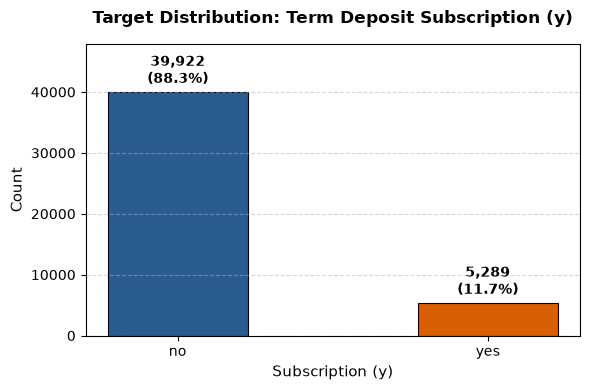

In [12]:
# Simple bar chart showing target distribution (yes vs no) using matplotlib
fig, ax = plt.subplots(figsize=(6, 4))
labels = target_summary.index.tolist()
counts = target_summary["Count"].tolist()
pcts = target_summary["Percentage (%)"].tolist()

bars = ax.bar(labels, counts, color=["#2b5c8f", "#d95f02"], width=0.45, edgecolor="black", linewidth=0.8)

for bar, count, pct in zip(bars, counts, pcts):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 800, f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Target Distribution: Term Deposit Subscription (y)", fontsize=12, fontweight="bold", pad=15)
ax.set_xlabel("Subscription (y)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_ylim(0, max(counts) * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observations on Target Distribution

- **Is the target balanced?**
  No, the target is heavily imbalanced. Approximately **88.30%** of customers did not subscribe (`no`), while only **11.70%** subscribed (`yes`).
- **Which class is the minority class?**
  The minority class is **`yes`** (5,289 instances out of 45,211).
- **Why could this matter later for model evaluation?**
  A naive baseline model predicting `no` for every customer would achieve **88.30% accuracy** while having a recall of 0% on the customers who actually subscribed, completely failing the business goal. Standard accuracy is misleading in this context (the accuracy paradox). Model evaluation must rely on metrics such as Precision, Recall, F1-Score, and PR-AUC, and class-balancing techniques (e.g. class weighting, SMOTE, or undersampling) will be explored.

> **Notice**: We do not perform class balancing yet.

# 6. Prepare Features and Target

In this section, we prepare our feature matrix `X` and target vector `y` while carefully handling potential data leakage.

In [13]:
# Preserve the original raw DataFrame
df_raw = df.copy()

# Define target vector y and initial feature matrix X
y = df["y"]
X = df.drop(columns=["y"])

# Handle Potential Data Leakage: drop duration from X for the realistic modelling dataset
X = X.drop(columns=["duration"])

print("df_raw shape (retains duration & target):", df_raw.shape)
print("X shape (features without target & duration):", X.shape)
print("y shape (target vector):", y.shape)
print("\nIs 'duration' in df_raw?:", "duration" in df_raw.columns)
print("Is 'duration' in X?:", "duration" in X.columns)

df_raw shape (retains duration & target): (45211, 17)
X shape (features without target & duration): (45211, 15)
y shape (target vector): (45211,)

Is 'duration' in df_raw?: True
Is 'duration' in X?: False


### Handling Potential Data Leakage: Why `duration` is Dropped

The feature **`duration`** represents the duration of the marketing phone call in seconds.

The business goal is to decide which customers should be contacted before the phone call happens. Since call duration is unavailable before the call (only known after or during the call), using it would leak future information into the model.

- If a model is trained using `duration`, it learns that very long calls strongly predict subscription. While true retrospectively, this information is completely unavailable to the sales team when selecting leads to call tomorrow morning.
- Including `duration` creates an unrealistic model: the model cannot be used reliably for pre-call prediction because duration is unavailable at the prediction moment.
- Therefore, we drop `duration` from `X` for our realistic predictive modelling dataset.
- Crucially, we **do not delete `duration` from `df_raw`**. We preserve the raw dataset intact for benchmark comparisons, historical auditing, and comparative leakage experiments later in the project.
- Also note: `y` is **not encoded yet**.

# 7. Train/Test Split

We partition the data into training and test sets using `train_test_split` from `sklearn.model_selection`.

In [14]:
from sklearn.model_selection import train_test_split

# Perform stratified train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\ny_train target distribution (counts):")
print(y_train.value_counts())
print("\ny_train target percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2).astype(str) + "%")

print("\ny_test target distribution (counts):")
print(y_test.value_counts())
print("\ny_test target percentages:")
print((y_test.value_counts(normalize=True) * 100).round(2).astype(str) + "%")

X_train shape: (36168, 15)
X_test shape: (9043, 15)
y_train shape: (36168,)
y_test shape: (9043,)

y_train target distribution (counts):
y
no     31937
yes     4231
Name: count, dtype: int64

y_train target percentages:
y
no     88.3%
yes    11.7%
Name: proportion, dtype: str

y_test target distribution (counts):
y
no     7985
yes    1058
Name: count, dtype: int64

y_test target percentages:
y
no     88.3%
yes    11.7%
Name: proportion, dtype: str


### Observations on Stratified Train/Test Split

#### Why `stratify=y` Matters:
The target is imbalanced, so stratification preserves approximately the same yes/no ratio in both train and test sets.

Without stratification, random sampling could produce an unrepresentative test set with too few minority class (`yes`) instances or a divergent class distribution, skewing performance evaluation.

#### Verification of Ratios:
- **`y_train` distribution**: **88.30%** `no` (31,937 instances) vs. **11.70%** `yes` (4,231 instances)
- **`y_test` distribution**: **88.30%** `no` (7,985 instances) vs. **11.70%** `yes` (1,058 instances)
- Both sets strictly mirror the overall population ratio (`yes` ≈ 11.7%, `no` ≈ 88.3%).

# 8. Decide How to Treat "unknown"

In real-world data preparation, we **do not treat all "unknown" values the same**. We adopt a domain-aware decision for each column:

- **`job`**: `"unknown"` → treat as missing
- **`education`**: `"unknown"` → treat as missing
- **`contact`**: keep `"unknown"` as a valid category for now
- **`poutcome`**: keep `"unknown"` as a valid category for now

### Rationale:
- **`job` and `education`** have relatively few unknown values (0.64% and 4.11%), so we will treat them as missing information.
- **`contact`** has many unknown values (28.80%), so replacing all of them with the most frequent value could distort the data.
- **`poutcome`** has over 80% unknown values (81.75%), so imputing them would be especially aggressive and potentially misleading.
- Therefore, **`contact`** and **`poutcome`** remain explicit categories for now.

We apply the replacement `"unknown"` → `np.nan` separately to `X_train` and `X_test` for `job` and `education` only, without touching `df_raw` or `df`.

In [15]:
# Explicitly copy to avoid SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# Replace "unknown" with np.nan ONLY for job and education in X_train and X_test
X_train["job"] = X_train["job"].replace("unknown", np.nan)
X_train["education"] = X_train["education"].replace("unknown", np.nan)

X_test["job"] = X_test["job"].replace("unknown", np.nan)
X_test["education"] = X_test["education"].replace("unknown", np.nan)

print("Missing values (NaN) in X_train after replacement:")
print(X_train[["job", "education"]].isnull().sum())

print("\nMissing values (NaN) in X_test after replacement:")
print(X_test[["job", "education"]].isnull().sum())

print("\nVerification of remaining 'unknown' categories in X_train:")
print("X_train['contact'] unknown count:", (X_train["contact"] == "unknown").sum())
print("X_train['poutcome'] unknown count:", (X_train["poutcome"] == "unknown").sum())

print("\nVerification of remaining 'unknown' categories in X_test:")
print("X_test['contact'] unknown count:", (X_test["contact"] == "unknown").sum())
print("X_test['poutcome'] unknown count:", (X_test["poutcome"] == "unknown").sum())

Missing values (NaN) in X_train after replacement:
job           234
education    1482
dtype: int64

Missing values (NaN) in X_test after replacement:
job           54
education    375
dtype: int64

Verification of remaining 'unknown' categories in X_train:
X_train['contact'] unknown count: 10386
X_train['poutcome'] unknown count: 29589

Verification of remaining 'unknown' categories in X_test:
X_test['contact'] unknown count: 2634
X_test['poutcome'] unknown count: 7370


### Observations on "Unknown" Replacement
- In `X_train`, `job` now has **234** missing values and `education` has **1,482** missing values.
- In `X_test`, `job` now has **54** missing values and `education` has **375** missing values.
- `contact` and `poutcome` retain their `"unknown"` categories intact (10,386 and 29,589 in train; 2,634 and 7,370 in test).
- The raw dataset `df_raw` and original `df` remain completely untouched.

# 9. SimpleImputer

We now impute the missing values in `job` and `education` using scikit-learn's `SimpleImputer` with `strategy="most_frequent"`.

### Understanding `fit()` vs `transform()`
- **`fit()`**: Learns the most frequent category (mode) from the **training data only**.
- **`transform()`**: Applies the learned replacement category to fill missing values in **both train and test data**.

### Why Fitting on the Full Dataset Would Create Data Leakage:
If we called `imputer.fit()` on the entire dataset (combining training and test data) before splitting, information from the unseen test set would influence the learned mode. In production, future test clients are completely unknown. Preprocessing must strictly learn statistics from the training set alone, preventing test set data leakage into the training pipeline.

In [16]:
from sklearn.impute import SimpleImputer

# Create categorical imputer using the most frequent strategy
imputer = SimpleImputer(strategy="most_frequent")

# Fit ONLY on X_train[["job", "education"]]
imputer.fit(X_train[["job", "education"]])

# Display learned statistics and clearly map them to columns
learned_stats = pd.Series(
    imputer.statistics_,
    index=["job", "education"],
    name="Learned Imputation Value"
)

print("Imputer Learned Statistics (imputer.statistics_):")
print(learned_stats)

# Transform both X_train and X_test, restoring transformed columns back into DataFrames
X_train[["job", "education"]] = imputer.transform(X_train[["job", "education"]])
X_test[["job", "education"]] = imputer.transform(X_test[["job", "education"]])

print("\nMissing values in X_train after imputation:")
print(X_train[["job", "education"]].isnull().sum())

print("\nMissing values in X_test after imputation:")
print(X_test[["job", "education"]].isnull().sum())

Imputer Learned Statistics (imputer.statistics_):
job          blue-collar
education      secondary
Name: Learned Imputation Value, dtype: str

Missing values in X_train after imputation:
job          0
education    0
dtype: int64

Missing values in X_test after imputation:
job          0
education    0
dtype: int64


### Mapping of Learned Imputation Values
- **`job`** → Learned most frequent value: **`blue-collar`**
- **`education`** → Learned most frequent value: **`secondary`**

All missing values in `job` and `education` have been successfully resolved across both `X_train` and `X_test` with **0 remaining NaNs**.

# 10. Step 2 Verification

We run a formal verification check across all requirements of Step 2.

In [17]:
# Verification Checklist for Step 2
checks_step2 = {
    "df_raw still contains duration": "duration" in df_raw.columns,
    "X does not contain duration": "duration" not in X.columns,
    "X_train does not contain duration": "duration" not in X_train.columns,
    "X_test does not contain duration": "duration" not in X_test.columns,
    "raw df remains unchanged (shape 45211, 17)": df.shape == (45211, 17) and "duration" in df.columns,
    "job has no missing values in X_train": X_train["job"].isnull().sum() == 0,
    "education has no missing values in X_train": X_train["education"].isnull().sum() == 0,
    "job has no missing values in X_test": X_test["job"].isnull().sum() == 0,
    "education has no missing values in X_test": X_test["education"].isnull().sum() == 0,
    "contact still contains 'unknown' in X_train": (X_train["contact"] == "unknown").sum() > 0,
    "poutcome still contains 'unknown' in X_train": (X_train["poutcome"] == "unknown").sum() > 0,
    "contact still contains 'unknown' in X_test": (X_test["contact"] == "unknown").sum() > 0,
    "poutcome still contains 'unknown' in X_test": (X_test["poutcome"] == "unknown").sum() > 0,
    "train/test class ratios equal (within 0.05%)": abs((y_train == "yes").mean() - (y_test == "yes").mean()) < 0.0005,
    "no encoding performed (job is still str/object)": X_train["job"].dtype in ("object", "str"),
    "no scaling performed (balance has original range)": X_train["balance"].max() > 10000,
    "no balancing performed (train minority is ~11.7%)": round((y_train == "yes").mean() * 100, 1) == 11.7
}

verification_step2_df = pd.DataFrame(list(checks_step2.items()), columns=["Verification Criterion", "Status"])
display(verification_step2_df)
assert all(checks_step2.values()), "One or more Step 2 verification checks failed!"

,Verification Criterion,Status
0,df_raw still contains duration,True
1,X does not contain duration,True
2,X_train does not contain duration,True
3,X_test does not contain duration,True
4,"raw df remains unchanged (shape 45211, 17)",True
5,job has no missing values in X_train,True
6,education has no missing values in X_train,True
7,job has no missing values in X_test,True
8,education has no missing values in X_test,True
9,contact still contains 'unknown' in X_train,True


# 11. Summary of Step 2

### Q&A
- **How was data leakage handled?**
  The `duration` feature was identified as potential data leakage and dropped from the modeling feature matrix `X`, `X_train`, and `X_test`. It was preserved in `df_raw` for future benchmark comparisons.
- **Why was `stratify=y` chosen for the train/test split?**
  Due to severe target imbalance (~88.3% `no` vs. ~11.7% `yes`), stratified splitting ensures identical class proportions in both sets (31,937 vs. 4,231 in train; 7,985 vs. 1,058 in test).
- **How were "unknown" categories treated?**
  A nuanced approach was applied: `job` (0.64%) and `education` (4.11%) were treated as true missing data and imputed; `contact` (28.80%) and `poutcome` (81.75%) were retained as valid explicit categories to prevent severe distributional distortion.
- **What values were learned by the imputer?**
  `job` was imputed with `'blue-collar'`, and `education` was imputed with `'secondary'`, strictly learned from `X_train`.

# 12. Inspect Numerical Features & Potential Outlier Detection

In Step 3, we inspect the distribution, skewness, and potential outliers of the numerical features in our modeling dataset, and formulate a principled feature scaling strategy.

We work from the already prepared `X_train` and `X_test` without modifying them directly.

We create dedicated scaled copies:
```python
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
```

The numerical features in our modeling dataset are:
- `age`
- `balance`
- `day`
- `campaign`
- `pdays`
- `previous`
*(Recall that `duration` was removed as future data leakage in Step 2).*

In [18]:
# Create dedicated scaled copies to preserve original X_train and X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Define numerical columns present in modeling dataset
numerical_cols = ["age", "balance", "day", "campaign", "pdays", "previous"]

# Compute compact numerical summary statistics on training data
num_summary = pd.DataFrame({
    "min": X_train[numerical_cols].min(),
    "max": X_train[numerical_cols].max(),
    "mean": X_train[numerical_cols].mean(),
    "median": X_train[numerical_cols].median(),
    "std": X_train[numerical_cols].std(),
    "skewness": X_train[numerical_cols].skew()
})

print("Numerical Features Summary (X_train):")
display(num_summary.round(2))

Numerical Features Summary (X_train):


,min,max,mean,median,std,skewness
age,18,95,40.89,39.0,10.63,0.69
balance,-8019,102127,1365.49,451.0,3068.54,8.34
day,1,31,15.82,16.0,8.33,0.09
campaign,1,63,2.76,2.0,3.10,4.94
pdays,-1,871,40.16,-1.0,100.16,2.62
previous,0,275,0.58,0.0,2.41,45.03


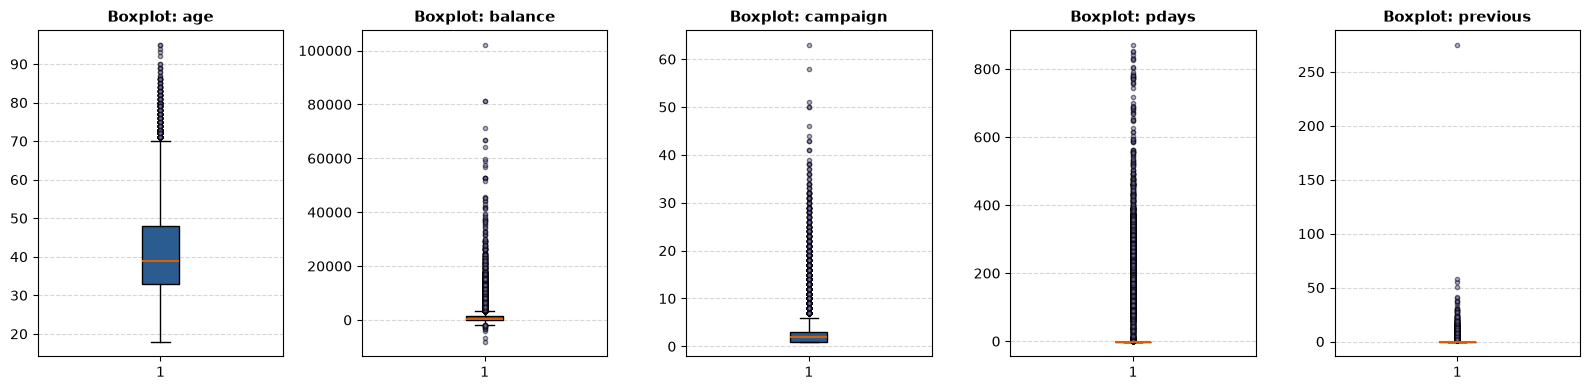

In [19]:
# Create boxplots for key numerical features using matplotlib
boxplot_features = ["age", "balance", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for ax, col in zip(axes, boxplot_features):
    ax.boxplot(
        X_train[col],
        patch_artist=True,
        boxprops=dict(facecolor="#2b5c8f", color="black"),
        medianprops=dict(color="#d95f02", linewidth=1.5),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(marker="o", markerfacecolor="#7570b3", markersize=3, alpha=0.5)
    )
    ax.set_title(f"Boxplot: {col}", fontsize=11, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observations on Numerical Features & Skewness
- **`age`** (skew = **0.69**): Mild positive skewness. Mean (40.89) and median (39.0) are very close.
- **`day`** (skew = **0.09**): Near zero skewness. Well-behaved uniform distribution across the month (1 to 31).
- **`balance`** (skew = **8.34**): **Strongly right-skewed**. Median is $451.0, while mean is $1,365.49 and maximum is $102,127, alongside negative balances down to -$8,019.
- **`campaign`** (skew = **4.94**): **Strongly right-skewed**. Most clients received 1 to 3 contacts, but extreme values reach up to 63 contacts.
- **`pdays`** (skew = **2.62**): Bimodal / skewed. Over 80% of rows contain `-1` (meaning not previously contacted).
- **`previous`** (skew = **45.03**): **Extremely right-skewed**. Median is 0.0, 75th percentile is 0.0, but maximum is 275 previous contacts.

---

### Potential Outlier Detection via IQR Rule

We inspect potential outliers using the standard Interquartile Range (IQR) rule:
$$\text{IQR} = Q_3 - Q_1$$
$$\text{Potential Outlier} \iff x < Q_1 - 1.5 \times \text{IQR} \quad \text{or} \quad x > Q_3 + 1.5 \times \text{IQR}$$

In [20]:
# Calculate potential outliers using the IQR rule for inspection only
outlier_cols = ["age", "balance", "campaign", "previous"]
outlier_records = []

for col in outlier_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = (X_train[col] < lower_bound) | (X_train[col] > upper_bound)
    count = outliers.sum()
    pct = (count / len(X_train)) * 100
    
    outlier_records.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": count,
        "outlier_percentage": pct
    })

outlier_df = pd.DataFrame(outlier_records)
print("Potential Outlier Audit (IQR Rule on X_train):")
display(outlier_df.round(2))

Potential Outlier Audit (IQR Rule on X_train):


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,age,33.0,48.00,15.00,10.50,70.50,394,1.09
1,balance,74.0,1430.25,1356.25,-1960.38,3464.62,3770,10.42
2,campaign,1.0,3.00,2.00,-2.00,6.00,2465,6.82
3,previous,0.0,0.00,0.00,0.00,0.00,6584,18.20


### Critical Analysis of Potential Outliers

#### Summary of IQR Findings on `X_train` (36,168 rows):
- **`age`**: **394 potential outliers** (**1.09%**). Upper bound is 70.5 years. Clients aged 71 to 95 are seniors, which is a legitimate and valid customer demographic.
- **`balance`**: **3,770 potential outliers** (**10.42%**). Values below -$1,962.62 or above $3,462.38. High account balances and overdrafts reflect real financial heterogeneity.
- **`campaign`**: **2,465 potential outliers** (**6.82%**). Upper bound is 6.0 contacts. Clients contacted 7 to 63 times are persistent campaign follow-ups.
- **`previous`**: **6,584 potential outliers** (**18.20%**). Because Q1 = 0 and Q3 = 0, IQR = 0, meaning any client contacted even once previously is flagged as an outlier by the mechanical IQR rule.
- **`pdays` (Special Business Case)**:
  - `pdays = -1` has a specific business meaning: **the customer was not previously contacted**.
  - Over 80% of values are `-1`.
  - **Do NOT treat `-1` automatically as an outlier or invalid value.** It is a sentinel code that will be engineered into dedicated indicators during Feature Creation.

> ### ⚠️ Key Domain Principle:
> **An outlier is not necessarily an error.**
> Extreme values may be legitimate observations and should not be removed without business justification.
>
> **Do NOT remove any rows.** All 36,168 training observations and 9,043 test observations are preserved intact.

# 13. Scaling Strategy

We formulate a practical, lesson-grounded scaling strategy tailored to the specific distributional properties of each numerical feature.

---

## Scaling Strategy Comparison

### 1. `StandardScaler`
- **Formula**: $z = \frac{x - \mu}{\sigma}$
- **Properties**: Centers the data around mean $\mu = 0$ and scales to unit standard deviation $\sigma = 1$.
- **When to Use**: Ideal for features that are reasonably well-behaved, symmetric, or moderately skewed.
- **Limitation**: Highly sensitive to extreme outliers because both sample mean and standard deviation are heavily pulled by extreme tails.
- **Assigned Features**:
  - **`age`**: Well-behaved distribution (skew = 0.69).
  - **`day`**: Nearly uniform distribution across days of the month (skew = 0.09).

### 2. `RobustScaler`
- **Formula**: $z = \frac{x - \text{median}}{\text{IQR}}$
- **Properties**: Centers the data using the median and scales using the Interquartile Range ($Q_3 - Q_1$).
- **When to Use**: Robust to extreme outliers and heavy skewness because median and IQR are robust statistics (unaffected by extreme values in the tails).
- **Assigned Features**:
  - **`balance`**: Heavily skewed (skew = 8.34) with extreme account balances up to $102,127$.
  - **`campaign`**: Heavily skewed (skew = 4.94) with extreme contacts up to 63.
  - **`previous`**: Heavily skewed (skew = 45.03) with extreme previous contacts up to 275.

### 3. What About `MinMaxScaler`?
- **Formula**: $z = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$
- **Properties**: Bounds values strictly to $[0, 1]$.
- **Why NOT selected**: `MinMaxScaler` compresses the vast majority of inlier data into a tiny sub-interval (e.g. $[0, 0.05]$) when extreme maximum outliers exist (such as balance of $102,127$ or previous contacts of 275). It exists and is valuable for bounded inputs (e.g. image pixels), but is not the best choice for these skewed financial features.

### 4. Why `pdays` is NOT Scaled Yet:
- **`pdays` contains the special sentinel value `-1`**, meaning the customer was not previously contacted.
- Scaling `-1` alongside continuous elapsed days (up to 871) creates a mathematically distorted hybrid.
- We will handle its domain business meaning in Section 22 during **Feature Creation**.

---

## Fit Scalers ONLY on Training Data

> **Rule**: Scalers must be fitted **ONLY on `X_train`**.
> We then use the fitted scalers to transform both `X_train_scaled` and `X_test_scaled`.
> **Never call `fit()` or `fit_transform()` on `X_test`**, as doing so would leak test distribution parameters into preprocessing.

In [21]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# Define feature groups based on scaling strategy
standard_features = ["age", "day"]
robust_features = ["balance", "campaign", "previous"]

# Instantiate scalers
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Fit both scalers ONLY on training data
standard_scaler.fit(X_train[standard_features])
robust_scaler.fit(X_train[robust_features])

# Transform X_train_scaled and X_test_scaled (DO NOT fit on X_test)
X_train_scaled[standard_features] = standard_scaler.transform(X_train[standard_features])
X_test_scaled[standard_features] = standard_scaler.transform(X_test[standard_features])

X_train_scaled[robust_features] = robust_scaler.transform(X_train[robust_features])
X_test_scaled[robust_features] = robust_scaler.transform(X_test[robust_features])

print("Scalers successfully fitted on X_train and applied to both train and test sets!")

Scalers successfully fitted on X_train and applied to both train and test sets!


# 14. Verify Scaling

We inspect the resulting distributions of the scaled features on the training set to verify mathematical correctness.

In [22]:
# Verify StandardScaler features on X_train_scaled (Expect: mean ≈ 0, std ≈ 1)
std_verification = pd.DataFrame({
    "Mean (Scaled)": X_train_scaled[standard_features].mean(),
    "Std (Scaled)": X_train_scaled[standard_features].std()
})

print("StandardScaler Features Verification (X_train_scaled):")
display(std_verification.round(6))

# Verify RobustScaler features on X_train_scaled (Expect: median ≈ 0, IQR ≈ 1 where IQR > 0)
q25 = X_train_scaled[robust_features].quantile(0.25)
q75 = X_train_scaled[robust_features].quantile(0.75)
iqr_scaled = q75 - q25

robust_verification = pd.DataFrame({
    "Median (Scaled)": X_train_scaled[robust_features].median(),
    "IQR (Scaled)": iqr_scaled
})

print("\nRobustScaler Features Verification (X_train_scaled):")
display(robust_verification.round(6))

StandardScaler Features Verification (X_train_scaled):


,Mean (Scaled),Std (Scaled)
age,-0.0,1.000014
day,0.0,1.000014



RobustScaler Features Verification (X_train_scaled):


,Median (Scaled),IQR (Scaled)
balance,0.0,1.0
campaign,0.0,1.0
previous,0.0,0.0


### Observations on Scaled Distributions & Important Technical Note on `previous`

#### StandardScaler Features (`age`, `day`):
- `age`: Mean = **0.000000**, Std = **1.000014** (mean ≈ 0, std ≈ 1)
- `day`: Mean = **0.000000**, Std = **1.000014** (mean ≈ 0, std ≈ 1)

#### RobustScaler Features (`balance`, `campaign`, `previous`):
- `balance`: Median = **0.000000**, IQR = **1.000000** (median ≈ 0, IQR ≈ 1)
- `campaign`: Median = **0.000000**, IQR = **1.000000** (median ≈ 0, IQR ≈ 1)
- **`previous`**: Median = **0.000000**, IQR = **0.000000**

> ### 📌 Technical Correction regarding `previous`:
> For the feature **`previous`**, $Q_1 = Q_3 = 0$, therefore its original IQR is strictly **0**.
> **Do NOT claim that RobustScaler makes the IQR of "previous" approximately 1.**
> When the IQR is zero, RobustScaler cannot normalize the IQR in the usual way (dividing by IQR) because division by zero is undefined. In such cases, scikit-learn uses a **safe scaling fallback** (`scale_ = 1.0`), centering values by subtracting the median ($0.0$) without dividing by zero.
> As a result, the scaled median is $0.0$ and the scaled IQR remains $0.0$, rather than $1.0$.

In [23]:
# Display before and after scaling comparison for a few rows
sample_indices = X_train.index[:5]
comparison_cols = ["age", "balance", "campaign", "day", "previous", "pdays"]

print("Before Scaling (Original X_train):")
display(X_train.loc[sample_indices, comparison_cols])

print("\nAfter Scaling (X_train_scaled):")
display(X_train_scaled.loc[sample_indices, comparison_cols].round(4))

Before Scaling (Original X_train):


,age,balance,campaign,day,previous,pdays
24001,36,861,2,29,0,-1
43409,24,4126,4,5,7,185
20669,44,244,4,12,0,-1
18810,48,0,11,31,0,-1
23130,38,257,10,26,0,-1



After Scaling (X_train_scaled):


,age,balance,campaign,day,previous,pdays
24001,-0.4604,0.3023,0.0,1.5821,0.0,-1
43409,-1.5896,2.7097,1.0,-1.2984,7.0,185
20669,0.2924,-0.1526,1.0,-0.4582,0.0,-1
18810,0.6688,-0.3325,4.5,1.8222,0.0,-1
23130,-0.2722,-0.1430,4.0,1.2221,0.0,-1


# 15. Important Integrity Checks

We programmatically verify all constraints and safeguards for Step 3.

In [24]:
# Step 3 Integrity Checks
checks_step3 = {
    "original X_train remains unchanged (age mean matches)": abs(X_train["age"].mean() - 40.892999) < 0.001,
    "original X_test remains unchanged (age mean matches)": abs(X_test["age"].mean() - 41.109145) < 0.001,
    "X_train_scaled contains scaled numerical values (age mean ≈ 0)": abs(X_train_scaled["age"].mean()) < 1e-5,
    "X_test_scaled contains scaled numerical values (age std ≈ 1)": abs(X_test_scaled["age"].std() - 1.0) < 0.05,
    "no rows were removed (X_train_scaled has 36168 rows)": len(X_train_scaled) == 36168,
    "no rows were removed (X_test_scaled has 9043 rows)": len(X_test_scaled) == 9043,
    "pdays remains completely unchanged in X_train_scaled": (X_train_scaled["pdays"] == X_train["pdays"]).all(),
    "pdays remains completely unchanged in X_test_scaled": (X_test_scaled["pdays"] == X_test["pdays"]).all(),
    "categorical columns remain unencoded (job is still str/object)": X_train_scaled["job"].dtype in ("object", "str"),
    "target y remains untouched (shape 45211)": len(y) == 45211,
    "no balancing has occurred (y_train minority is ~11.7%)": round((y_train == "yes").mean() * 100, 1) == 11.7
}

verification_step3_df = pd.DataFrame(list(checks_step3.items()), columns=["Verification Criterion", "Status"])
display(verification_step3_df)
assert all(checks_step3.values()), "One or more Step 3 integrity checks failed!"

,Verification Criterion,Status
0,original X_train remains unchanged (age mean m...,True
1,original X_test remains unchanged (age mean ma...,True
2,X_train_scaled contains scaled numerical value...,True
3,X_test_scaled contains scaled numerical values...,True
4,no rows were removed (X_train_scaled has 36168...,True
5,no rows were removed (X_test_scaled has 9043 r...,True
6,pdays remains completely unchanged in X_train_...,True
7,pdays remains completely unchanged in X_test_s...,True
8,categorical columns remain unencoded (job is s...,True
9,target y remains untouched (shape 45211),True


### Note on Data Leakage Prevention

> **Data Leakage Prevention**:
> Scaling parameters (mean, standard deviation, median, IQR) must be learned **only from training data**.
> Using the full dataset would leak information from the test set into preprocessing, leading to overly optimistic test performance that fails to generalize to unseen production data.

# 16. Step 3 Findings

### Summary of Numerical Features & Potential Outliers:
- **Strong Skewness & Outlier-Heavy Features**:
  - `balance` (skewness = **8.34**, 3,770 IQR potential outliers / 10.42%)
  - `campaign` (skewness = **4.94**, 2,465 IQR potential outliers / 6.82%)
  - `previous` (skewness = **45.03**, 6,584 IQR potential outliers / 18.20%)
- **Well-Behaved Features**:
  - `age` (skewness = **0.69**, 394 IQR potential outliers / 1.09%)
  - `day` (skewness = **0.09**, 0 IQR potential outliers / 0.00%)
- **Why no outliers were automatically removed**:
  Outliers in customer banking data (such as high account balances, senior ages, or multiple contact attempts) represent legitimate financial client behavior. Removing them without strong business justification would distort real-world distribution and reduce model utility.
- **Why RobustScaler was selected**:
  For `balance` and `campaign`, `RobustScaler` scales using median and IQR, preventing extreme values from shrinking inlier data into near-zero ranges. For `previous`, where $Q_1 = Q_3 = 0$, `RobustScaler` safely centers at 0 and falls back to unit scale to avoid division by zero.
- **Why StandardScaler was selected**:
  For `age` and `day`, `StandardScaler` standardizes moderately distributed features to mean 0 and unit variance.
- **Why `pdays` was intentionally left unchanged**:
  `pdays` contains the sentinel value `-1` representing uncontacted clients. Scaling it directly would distort the categorical boundary. It is now handled in Step 5.

# 17. Inspect Categorical Features

We now review the categorical features in our modeling dataset:
- `job`
- `marital`
- `education`
- `default`
- `housing`
- `loan`
- `contact`
- `month`
- `poutcome`

*(Recall that `job` and `education` have already been imputed using SimpleImputer in Step 2, while `contact` and `poutcome` explicitly retained `"unknown"` as a valid category).*

In [25]:
# Define categorical features in the modeling dataset
categorical_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

# Display unique category counts, names, and frequency distributions on training data
cat_inspection_records = []
for col in categorical_features:
    categories = sorted(X_train_scaled[col].unique().tolist())
    cat_inspection_records.append({
        "Feature": col,
        "Unique Categories Count": len(categories),
        "Category Names": ", ".join(categories)
    })

cat_inspection_df = pd.DataFrame(cat_inspection_records)
print("Categorical Features Overview (X_train_scaled):")
display(cat_inspection_df)

print("\nCategory Value Counts (Training Set Frequencies):")
for col in categorical_features:
    print(f"\n--- {col} ({X_train_scaled[col].nunique()} categories) ---")
    print(X_train_scaled[col].value_counts().to_string())

Categorical Features Overview (X_train_scaled):


,Feature,Unique Categories Count,Category Names
0,job,11,"admin., blue-collar, entrepreneur, housemaid, ..."
1,marital,3,"divorced, married, single"
2,education,3,"primary, secondary, tertiary"
3,default,2,"no, yes"
4,housing,2,"no, yes"
5,loan,2,"no, yes"
6,contact,3,"cellular, telephone, unknown"
7,month,12,"apr, aug, dec, feb, jan, jul, jun, mar, may, n..."
8,poutcome,4,"failure, other, success, unknown"



Category Value Counts (Training Set Frequencies):

--- job (11 categories) ---
job
blue-collar      8064
management       7511
technician       6068
admin.           4141
services         3348
retired          1812
self-employed    1243
entrepreneur     1186
unemployed       1024
housemaid        1013
student           758

--- marital (3 categories) ---
marital
married     21771
single      10227
divorced     4170

--- education (3 categories) ---
education
secondary    20043
tertiary     10594
primary       5531

--- default (2 categories) ---
default
no     35521
yes      647

--- housing (2 categories) ---
housing
yes    20182
no     15986

--- loan (2 categories) ---
loan
no     30355
yes     5813

--- contact (3 categories) ---
contact
cellular     23465
unknown      10386
telephone     2317

--- month (12 categories) ---
month
may    11062
jul     5537
aug     4986
jun     4237
nov     3143
apr     2394
feb     2078
jan     1119
oct      592
sep      451
mar      391
dec      1

### Observations on Categorical Features
- **Binary Features (2 categories)**:
  - `default`: `'no'`, `'yes'`
  - `housing`: `'no'`, `'yes'`
  - `loan`: `'no'`, `'yes'`
- **Low Cardinality (3 to 4 categories)**:
  - `marital`: `'divorced'`, `'married'`, `'single'` (3 categories)
  - `education`: `'primary'`, `'secondary'`, `'tertiary'` (3 categories; `'unknown'` was imputed with mode `'secondary'`)
  - `contact`: `'cellular'`, `'telephone'`, `'unknown'` (3 categories; `'unknown'` preserved)
  - `poutcome`: `'failure'`, `'other'`, `'success'`, `'unknown'` (4 categories; `'unknown'` preserved)
- **Moderate / Higher Cardinality (11 to 12 categories)**:
  - `job`: 11 categories (`'unknown'` was imputed with mode `'blue-collar'`)
  - `month`: 12 months (`'jan'` through `'dec'`)

# 18. Choose Encoding Strategy

Categorical features can either have:
- **a meaningful natural order** (ordinal)
- **no meaningful order** (nominal)

### Why `OrdinalEncoder` is NOT Appropriate Here:
`OrdinalEncoder` should only be used when category order has real, quantifiable meaning (e.g. `["low", "medium", "high"]` $\to 0, 1, 2$).

For this project, the categorical features do not have a useful ordinal relationship for this prediction problem:
- **`job`**: `management`, `technician`, `services`, `blue-collar`, etc. There is no natural hierarchy, rank, or progressive scale between professions. Imposing an arbitrary ordering would falsely imply numerical distances.
- **`marital`**: `single`, `married`, `divorced`. No numeric ordering should be implied between marital states.
- **`month`**: Although months have chronological calendar progression, encoding them as integers 1–12 would imply a linear numerical relationship that is not appropriate here.
- **`contact` and `poutcome`**: `"unknown"` remains an explicit category because we intentionally retained it earlier. Treating `"unknown"` as part of an ordinal scale is nonsensical.

### Why `OneHotEncoder` is Selected:
Therefore, we use **`OneHotEncoder`**. One-hot encoding creates separate binary dummy columns for each category, representing categorical membership without introducing artificial numeric distances or rankings.

### Configuring `OneHotEncoder`

We instantiate `OneHotEncoder` with two key parameters:

```python
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
    drop="if_binary"
)
```

1. **`handle_unknown="ignore"`**: Prevents errors if the test set encounters unseen categories during inference.
2. **`drop="if_binary"`**: Binary features such as `housing = yes / no` only need **one encoded column** (`housing_yes`), preventing multicollinearity.

> **Data Leakage Safeguard**:
> The encoder must be fitted **ONLY on `X_train_scaled[categorical_features]`**.

In [26]:
from sklearn.preprocessing import OneHotEncoder

# Instantiate OneHotEncoder
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
    drop="if_binary"
)

# Fit ONLY on training data
encoder.fit(X_train_scaled[categorical_features])

# Inspect learned categories and feature names
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

print(f"Number of categorical features BEFORE encoding: {len(categorical_features)}")
print(f"Number of encoded columns AFTER encoding: {len(encoded_feature_names)}")

print("\nSample of Generated Encoded Column Names (first 15):")
print(list(encoded_feature_names[:15]))

print("\nBinary Columns Encoded with drop='if_binary':")
binary_encoded_cols = [col for col in encoded_feature_names if col.startswith(("default_", "housing_", "loan_"))]
print(binary_encoded_cols)

print("\nVerification of Retained 'unknown' Columns:")
print("Is 'contact_unknown' present?:", "contact_unknown" in encoded_feature_names)
print("Is 'poutcome_unknown' present?:", "poutcome_unknown" in encoded_feature_names)

Number of categorical features BEFORE encoding: 9
Number of encoded columns AFTER encoding: 39

Sample of Generated Encoded Column Names (first 15):
['job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'education_primary']

Binary Columns Encoded with drop='if_binary':
['default_yes', 'housing_yes', 'loan_yes']

Verification of Retained 'unknown' Columns:
Is 'contact_unknown' present?: True
Is 'poutcome_unknown' present?: True


# 19. Build Fully Numeric Feature Matrices

We transform the categorical columns and construct the fully numeric matrices:
- `X_train_encoded`
- `X_test_encoded`

Starting from `X_train_scaled` and `X_test_scaled`:
1. Transform categorical columns with the fitted encoder.
2. Remove original string categorical columns.
3. Concatenate the scaled numerical features, unscaled `pdays`, and new one-hot encoded columns.
4. Preserve the original DataFrame row indexes to keep all observations correctly aligned.

In [27]:
# Transform categorical features for train and test sets
train_cat_encoded = encoder.transform(X_train_scaled[categorical_features])
test_cat_encoded = encoder.transform(X_test_scaled[categorical_features])

# Convert encoded arrays to DataFrames preserving original indices
train_cat_df = pd.DataFrame(
    train_cat_encoded,
    columns=encoded_feature_names,
    index=X_train_scaled.index
)

test_cat_df = pd.DataFrame(
    test_cat_encoded,
    columns=encoded_feature_names,
    index=X_test_scaled.index
)

# Retain numerical features (scaled age, balance, day, campaign, previous, and unscaled pdays)
retained_num_cols = [col for col in X_train_scaled.columns if col not in categorical_features]

# Combine numerical and one-hot encoded features
X_train_encoded = pd.concat([X_train_scaled[retained_num_cols], train_cat_df], axis=1)
X_test_encoded = pd.concat([X_test_scaled[retained_num_cols], test_cat_df], axis=1)

print("Final Matrices Shape (X_train_encoded / X_test_encoded):")
print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape:  {X_test_encoded.shape}")

print("\nFirst 5 Rows of X_train_encoded (first 10 columns):")
display(X_train_encoded.iloc[:5, :10].round(4))

Final Matrices Shape (X_train_encoded / X_test_encoded):
X_train_encoded shape: (36168, 45)
X_test_encoded shape:  (9043, 45)

First 5 Rows of X_train_encoded (first 10 columns):


,age,balance,day,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid
24001,-0.4604,0.3023,1.5821,0.0,-1,0.0,0.0,0.0,0.0,0.0
43409,-1.5896,2.7097,-1.2984,1.0,185,7.0,0.0,0.0,0.0,0.0
20669,0.2924,-0.1526,-0.4582,1.0,-1,0.0,0.0,0.0,0.0,0.0
18810,0.6688,-0.3325,1.8222,4.5,-1,0.0,0.0,0.0,0.0,0.0
23130,-0.2722,-0.1430,1.2221,4.0,-1,0.0,0.0,0.0,0.0,0.0


# 20. Step 4 Verification

We execute a comprehensive automated verification suite across all requirements for Step 4.

In [28]:
# Comprehensive Verification Suite for Step 4
checks_step4 = {
    "X_train_encoded contains only numeric columns": all(np.issubdtype(dtype, np.number) for dtype in X_train_encoded.dtypes),
    "X_test_encoded contains only numeric columns": all(np.issubdtype(dtype, np.number) for dtype in X_test_encoded.dtypes),
    "no NaN values in X_train_encoded": X_train_encoded.isnull().sum().sum() == 0,
    "no NaN values in X_test_encoded": X_test_encoded.isnull().sum().sum() == 0,
    "original X_train remains unchanged (shape 36168, 15)": X_train.shape == (36168, 15),
    "original X_test remains unchanged (shape 9043, 15)": X_test.shape == (9043, 15),
    "X_train_scaled remains available (shape 36168, 15)": X_train_scaled.shape == (36168, 15),
    "X_test_scaled remains available (shape 9043, 15)": X_test_scaled.shape == (9043, 15),
    "job and education have 0 NaNs in X_train_scaled": X_train_scaled[["job", "education"]].isnull().sum().sum() == 0,
    "contact 'unknown' became an encoded category": "contact_unknown" in X_train_encoded.columns,
    "poutcome 'unknown' became an encoded category": "poutcome_unknown" in X_train_encoded.columns,
    "binary variables produce one column (default_yes)": "default_yes" in X_train_encoded.columns and "default_no" not in X_train_encoded.columns,
    "binary variables produce one column (housing_yes)": "housing_yes" in X_train_encoded.columns and "housing_no" not in X_train_encoded.columns,
    "binary variables produce one column (loan_yes)": "loan_yes" in X_train_encoded.columns and "loan_no" not in X_train_encoded.columns,
    "encoder fitted strictly on training data": len(encoder.categories_) == len(categorical_features),
    "row counts remain unchanged (train=36168, test=9043)": len(X_train_encoded) == 36168 and len(X_test_encoded) == 9043,
    "y_train remained untouched": len(y_train) == 36168 and (y_train.value_counts(normalize=True).round(3)["yes"] == 0.117),
    "y_test remained untouched": len(y_test) == 9043 and (y_test.value_counts(normalize=True).round(3)["yes"] == 0.117)
}

verification_step4_df = pd.DataFrame(list(checks_step4.items()), columns=["Verification Criterion", "Status"])
display(verification_step4_df)
assert all(checks_step4.values()), "One or more Step 4 verification checks failed!"

,Verification Criterion,Status
0,X_train_encoded contains only numeric columns,True
1,X_test_encoded contains only numeric columns,True
2,no NaN values in X_train_encoded,True
3,no NaN values in X_test_encoded,True
4,original X_train remains unchanged (shape 3616...,True
5,"original X_test remains unchanged (shape 9043,...",True
6,"X_train_scaled remains available (shape 36168,...",True
7,"X_test_scaled remains available (shape 9043, 15)",True
8,job and education have 0 NaNs in X_train_scaled,True
9,contact 'unknown' became an encoded category,True


# 21. Step 4 Encoding Findings

### Key Takeaways from Categorical Encoding:
- **Nominal Mapping**: OneHotEncoder avoids artificial linear ranking across unordered professions and statuses.
- **Leakage Safeguards**: Fitted strictly on training observations; unseen categories are safely handled via `handle_unknown="ignore"`.
- **Dimensionality Efficiency**: Binary columns produce single indicators (`drop="if_binary"`).
- **Explicit Unknowns**: `contact_unknown` (28.80%) and `poutcome_unknown` (81.75%) allow downstream models to learn domain missingness signals directly.
- **Resulting Matrix**: 45 numeric features across 36,168 training and 9,043 testing observations.

# 22. Feature Creation Strategy

In Step 5, we explore **Feature Creation and Discretization**.

## Strategy Overview
Feature engineering uses domain knowledge to convert raw variables into representations that may make useful patterns easier for a machine learning model to learn.

> ### ⚠️ Critical Principle:
> **New features are not automatically better features.**
> Their usefulness must later be evaluated using model performance and feature importance.

We construct three business-motivated transformations:
1. **`was_previously_contacted`**: Binary flag separating prior campaign exposure from uncontacted clients.
2. **`pdays_clean`**: A clean, non-negative numerical feature representing days elapsed since previous contact (with `-1` mapped to `0`), scaled via `MinMaxScaler`.
3. **`has_any_loan`**: A combined credit-risk indicator representing overall debt obligation (`housing` or `loan`).

And one discretized feature:
4. **`age_group`**: Binned demographic cohort representation (`18–30`, `31–45`, `46–60`, `60+`).

---

## 1. Handle the `pdays` Sentinel Value

Recall that:
$$\text{pdays} = -1$$
means **the customer was not previously contacted**.

Do **not** treat `-1` as a normal number of elapsed days. In linear models or distance-based algorithms, treating `-1` as smaller than `0` creates false numeric continuity where "never contacted" appears closer to "contacted today" than "contacted last week".

Using the **ORIGINAL prepared `X_train` and `X_test` values**, we construct:
- **`was_previously_contacted`**:
  - `1` $\iff \text{pdays} \neq -1$
  - `0` $\iff \text{pdays} == -1$
- **`pdays_clean`**:
  - $\text{pdays} == -1 \implies 0$
  - $\text{otherwise} \implies \text{original pdays}$

Example:
- `pdays = -1` $\implies$ `was_previously_contacted = 0`, `pdays_clean = 0`
- `pdays = 120` $\implies$ `was_previously_contacted = 1`, `pdays_clean = 120`

Separating the sentinel flag from the numerical duration preserves the business meaning much more clearly and eliminates artificial mathematical distortion.

In [29]:
# Create was_previously_contacted and pdays_clean from original X_train and X_test pdays
train_was_prev = (X_train["pdays"] != -1).astype(int)
test_was_prev = (X_test["pdays"] != -1).astype(int)

train_pdays_clean = X_train["pdays"].apply(lambda v: 0 if v == -1 else v)
test_pdays_clean = X_test["pdays"].apply(lambda v: 0 if v == -1 else v)

print("Verification of pdays transformations (Train sample):")
sample_pdays_df = pd.DataFrame({
    "Original pdays": X_train["pdays"].iloc[:8],
    "was_previously_contacted": train_was_prev.iloc[:8],
    "pdays_clean": train_pdays_clean.iloc[:8]
})
display(sample_pdays_df)

pct_prev_contacted = train_was_prev.mean() * 100
print(f"Percentage of customers previously contacted (Train): {pct_prev_contacted:.2f}%")

Verification of pdays transformations (Train sample):


,Original pdays,was_previously_contacted,pdays_clean
24001,-1,0,0
43409,185,1,185
20669,-1,0,0
18810,-1,0,0
23130,-1,0,0
15058,-1,0,0
15908,-1,0,0
30424,-1,0,0


Percentage of customers previously contacted (Train): 18.20%


### 2. Scale `pdays_clean` with `MinMaxScaler`

We scale `pdays_clean` into the interval $[0, 1]$ using scikit-learn's `MinMaxScaler`.

#### Why `MinMaxScaler` is reasonable here:
- **Non-negativity**: `pdays_clean` is strictly non-negative ($0$ to $871$).
- **Meaningful Zero**: The value $0$ has real physical meaning ($0$ elapsed days, or not contacted with `was_previously_contacted = 0`).
- **Zero Preservation**: `MinMaxScaler` maps $0 \to 0$, preserving the baseline anchor.
- **Bounded Representation**: Compresses elapsed days into a clean, bounded $[0, 1]$ feature.

> **Data Leakage Safeguard**:
> `MinMaxScaler` is fitted **ONLY on the training version of `pdays_clean`**.
> We then transform both train and test sets without ever fitting on `X_test`.

In [30]:
from sklearn.preprocessing import MinMaxScaler

# Instantiate and fit MinMaxScaler ONLY on training pdays_clean
pdays_scaler = MinMaxScaler()
pdays_scaler.fit(train_pdays_clean.to_frame())

# Transform both train and test sets
train_pdays_clean_scaled = pdays_scaler.transform(train_pdays_clean.to_frame()).flatten()
test_pdays_clean_scaled = pdays_scaler.transform(test_pdays_clean.to_frame()).flatten()

print(f"pdays_clean scaled min/max (Train): {train_pdays_clean_scaled.min():.4f} / {train_pdays_clean_scaled.max():.4f}")
print(f"pdays_clean scaled min/max (Test):  {test_pdays_clean_scaled.min():.4f} / {test_pdays_clean_scaled.max():.4f}")

pdays_clean scaled min/max (Train): 0.0000 / 1.0000
pdays_clean scaled min/max (Test):  0.0000 / 0.9621


### 3. Create `has_any_loan`

Using the **ORIGINAL categorical values** from `X_train` and `X_test`:
- `has_any_loan = 1` $\iff$ `housing == "yes" OR loan == "yes"`
- `has_any_loan = 0` $\iff$ otherwise

#### Business Rationale:
This combines two related financial obligations (housing loan and personal credit loan) into a unified business-level debt indicator. A client committed to either debt instrument may have less discretionary liquidity to invest in a long-term term deposit.

> **Note**: We do **NOT** remove the original `housing_yes` and `loan_yes` encoded features.
> We intentionally keep both the original features and the engineered feature so their predictive usefulness can be evaluated later in feature selection.

In [31]:
# Create has_any_loan from original categorical features in X_train and X_test
train_has_any_loan = ((X_train["housing"] == "yes") | (X_train["loan"] == "yes")).astype(int)
test_has_any_loan = ((X_test["housing"] == "yes") | (X_test["loan"] == "yes")).astype(int)

pct_has_any_loan = train_has_any_loan.mean() * 100
print(f"Percentage of customers with any loan (housing or personal loan): {pct_has_any_loan:.2f}%")

loan_comparison_df = pd.DataFrame({
    "housing": X_train["housing"].iloc[:8],
    "loan": X_train["loan"].iloc[:8],
    "has_any_loan": train_has_any_loan.iloc[:8]
})
display(loan_comparison_df)

Percentage of customers with any loan (housing or personal loan): 62.12%


,housing,loan,has_any_loan
24001,no,no,0
43409,no,no,0
20669,yes,no,1
18810,no,no,0
23130,no,no,0
15058,no,yes,1
15908,yes,no,1
30424,no,yes,1


# 23. Discretize Age

We create a new categorical feature, **`age_group`**, derived from the **ORIGINAL unscaled `age` values** in `X_train` and `X_test`.

### Binning Strategy:
We define four demographic age brackets using `pd.cut`:
- **`18–30`**: Young adults / early career
- **`31–45`**: Core working-age adults
- **`46–60`**: Established / pre-retirement adults
- **`60+`**: Senior / retirement cohort

```python
pd.cut(
    age,
    bins=[17, 30, 45, 60, np.inf],
    labels=["18-30", "31-45", "46-60", "60+"],
    include_lowest=True
)
```

### Rationale & Context:
- Discretization converts a continuous feature into distinct categories.
- We keep the original continuous `age` feature (scaled `age`) as well.
- The `age_group` feature is an **experiment** and is not assumed to automatically improve model performance; its empirical impact will be verified in subsequent model validation.

In [32]:
# Create age_group separately for train and test from original unscaled age
train_age_group = pd.cut(
    X_train["age"],
    bins=[17, 30, 45, 60, np.inf],
    labels=["18-30", "31-45", "46-60", "60+"],
    include_lowest=True
).rename("age_group")

test_age_group = pd.cut(
    X_test["age"],
    bins=[17, 30, 45, 60, np.inf],
    labels=["18-30", "31-45", "46-60", "60+"],
    include_lowest=True
).rename("age_group")

age_dist_df = pd.DataFrame({
    "Count": train_age_group.value_counts(),
    "Percentage (%)": (train_age_group.value_counts(normalize=True) * 100).round(2)
})

print("Age Group Distribution in Training Data (X_train):")
display(age_dist_df)

Age Group Distribution in Training Data (X_train):


,Count,Percentage (%)
age_group,,
31-45,18985,52.49
46-60,10511,29.06
18-30,5703,15.77
60+,969,2.68


### Encode `age_group` with `OneHotEncoder`

We instantiate a dedicated `OneHotEncoder` specifically for `age_group`:
```python
age_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
```
- Fitted **ONLY** on the training `age_group` feature.
- Transformed on both train and test sets.
- Generates 4 binary dummy columns: `age_group_18-30`, `age_group_31-45`, `age_group_46-60`, `age_group_60+`.

In [33]:
# Instantiate and fit OneHotEncoder for age_group ONLY on training data
age_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
age_encoder.fit(train_age_group.to_frame())

age_group_cols = age_encoder.get_feature_names_out()
print("Generated age_group encoded column names:")
print(list(age_group_cols))

# Transform train and test age groups preserving indices
train_age_encoded_df = pd.DataFrame(
    age_encoder.transform(train_age_group.to_frame()),
    columns=age_group_cols,
    index=X_train.index
)

test_age_encoded_df = pd.DataFrame(
    age_encoder.transform(test_age_group.to_frame()),
    columns=age_group_cols,
    index=X_test.index
)

Generated age_group encoded column names:
['age_group_18-30', 'age_group_31-45', 'age_group_46-60', 'age_group_60+']


## Build Feature-Engineered Matrices

We construct the updated feature-engineered datasets:
- **`X_train_featured`**
- **`X_test_featured`**

Starting from `X_train_encoded` and `X_test_encoded`:
1. Drop the original raw `pdays` column.
2. Add `pdays_clean` (scaled by `MinMaxScaler`).
3. Add `was_previously_contacted`.
4. Add `has_any_loan`.
5. Add the 4 one-hot encoded `age_group` columns.
6. Retain original scaled `age`, `housing_yes`, and `loan_yes` without removal.

In [34]:
# Start from a copy of X_train_encoded and X_test_encoded
X_train_featured = X_train_encoded.copy()
X_test_featured = X_test_encoded.copy()

# Drop original pdays column
X_train_featured = X_train_featured.drop(columns=["pdays"])
X_test_featured = X_test_featured.drop(columns=["pdays"])

# Add engineered pdays features and debt indicator
X_train_featured["pdays_clean"] = train_pdays_clean_scaled
X_train_featured["was_previously_contacted"] = train_was_prev
X_train_featured["has_any_loan"] = train_has_any_loan

X_test_featured["pdays_clean"] = test_pdays_clean_scaled
X_test_featured["was_previously_contacted"] = test_was_prev
X_test_featured["has_any_loan"] = test_has_any_loan

# Concatenate one-hot encoded age_group columns
X_train_featured = pd.concat([X_train_featured, train_age_encoded_df], axis=1)
X_test_featured = pd.concat([X_test_featured, test_age_encoded_df], axis=1)

print("Dimensions Comparison:")
print(f"X_train_encoded shape (before feature engineering): {X_train_encoded.shape}")
print(f"X_train_featured shape (after feature engineering):  {X_train_featured.shape}")
print(f"X_test_encoded shape (before feature engineering):  {X_test_encoded.shape}")
print(f"X_test_featured shape (after feature engineering):   {X_test_featured.shape}")

# Display sample rows containing all newly engineered features
new_feature_names = ["pdays_clean", "was_previously_contacted", "has_any_loan"] + list(age_group_cols)
print("\nSample Rows of Newly Engineered Features (X_train_featured):")
display(X_train_featured[new_feature_names].iloc[:5].round(4))

Dimensions Comparison:
X_train_encoded shape (before feature engineering): (36168, 45)
X_train_featured shape (after feature engineering):  (36168, 51)
X_test_encoded shape (before feature engineering):  (9043, 45)
X_test_featured shape (after feature engineering):   (9043, 51)

Sample Rows of Newly Engineered Features (X_train_featured):


,pdays_clean,was_previously_contacted,has_any_loan,age_group_18-30,age_group_31-45,age_group_46-60,age_group_60+
24001,0.0000,0,0,0.0,1.0,0.0,0.0
43409,0.2124,1,0,1.0,0.0,0.0,0.0
20669,0.0000,0,1,0.0,1.0,0.0,0.0
18810,0.0000,0,0,0.0,0.0,1.0,0.0
23130,0.0000,0,0,0.0,1.0,0.0,0.0


# 24. Step 5 Verification

We execute an automated verification checklist across all requirements of Step 5.

In [35]:
# Comprehensive Verification Checklist for Step 5
checks_step5 = {
    "X_train_featured contains only numeric columns": all(np.issubdtype(dt, np.number) for dt in X_train_featured.dtypes),
    "X_test_featured contains only numeric columns": all(np.issubdtype(dt, np.number) for dt in X_test_featured.dtypes),
    "no NaN values in X_train_featured": X_train_featured.isnull().sum().sum() == 0,
    "no NaN values in X_test_featured": X_test_featured.isnull().sum().sum() == 0,
    "row count unchanged in train (36168)": len(X_train_featured) == 36168,
    "row count unchanged in test (9043)": len(X_test_featured) == 9043,
    "original X_train remains unchanged (shape 36168, 15)": X_train.shape == (36168, 15),
    "original X_test remains unchanged (shape 9043, 15)": X_test.shape == (9043, 15),
    "original X_train_encoded remains unchanged (shape 36168, 45)": X_train_encoded.shape == (36168, 45),
    "original X_test_encoded remains unchanged (shape 9043, 45)": X_test_encoded.shape == (9043, 45),
    "original pdays is NOT present in X_train_featured": "pdays" not in X_train_featured.columns,
    "original pdays is NOT present in X_test_featured": "pdays" not in X_test_featured.columns,
    "pdays_clean IS present in featured": "pdays_clean" in X_train_featured.columns,
    "was_previously_contacted IS present in featured": "was_previously_contacted" in X_train_featured.columns,
    "has_any_loan IS present in featured": "has_any_loan" in X_train_featured.columns,
    "all age_group encoded columns exist": all(col in X_train_featured.columns for col in age_group_cols),
    "scaled age is still retained": "age" in X_train_featured.columns,
    "housing_yes is still retained": "housing_yes" in X_train_featured.columns,
    "loan_yes is still retained": "loan_yes" in X_train_featured.columns,
    "y_train remained untouched (shape 36168)": len(y_train) == 36168 and (round((y_train == "yes").mean() * 100, 1) == 11.7),
    "y_test remained untouched (shape 9043)": len(y_test) == 9043 and (round((y_test == "yes").mean() * 100, 1) == 11.7)
}

verification_step5_df = pd.DataFrame(list(checks_step5.items()), columns=["Verification Criterion", "Status"])
display(verification_step5_df)
assert all(checks_step5.values()), "One or more Step 5 verification checks failed!"

,Verification Criterion,Status
0,X_train_featured contains only numeric columns,True
1,X_test_featured contains only numeric columns,True
2,no NaN values in X_train_featured,True
3,no NaN values in X_test_featured,True
4,row count unchanged in train (36168),True
5,row count unchanged in test (9043),True
6,original X_train remains unchanged (shape 3616...,True
7,"original X_test remains unchanged (shape 9043,...",True
8,original X_train_encoded remains unchanged (sh...,True
9,original X_test_encoded remains unchanged (sha...,True


# 25. Step 5 Feature Engineering Findings

### Summary of Engineered Transformations:

1. **`pdays` Sentinel Resolution**:
   - The artificial `-1` sentinel was cleanly decoupled into two complementary features:
     - **`was_previously_contacted`**: A clean binary flag identifying the **18.20%** of clients with prior campaign history vs. **81.80%** uncontacted clients.
     - **`pdays_clean`**: The true non-negative duration (in days) since last contact, scaled boundedly into $[0, 1]$ via `MinMaxScaler` fitted strictly on training data.
2. **`has_any_loan` Financial Aggregation**:
   - Synthesized the customer's overall debt exposure across housing and personal loans into a single business-level indicator.
   - **62.12%** of clients in the training set carry at least one loan obligation.
   - Both the component indicators (`housing_yes`, `loan_yes`) and the aggregate feature (`has_any_loan`) are preserved to test their complementary vs. redundant predictive power.
3. **`age_group` Demographic Discretization**:
   - Discretized continuous client age into four demographic segments:
     - **`18–30`**: 15.77%
     - **`31–45`**: 52.49% (majority cohort)
     - **`46–60`**: 29.06%
     - **`60+`**: 2.68% (senior cohort)
   - One-hot encoded into 4 numeric columns while retaining the continuous scaled `age` feature.
4. **Hypothesis-Driven Feature Engineering**:
   - These engineered features represent explicit business hypotheses rather than guaranteed improvements.
   - Some features are intentionally redundant with existing attributes (e.g. `has_any_loan` with `housing_yes`/`loan_yes`, `age_group` with `age`).
   - In subsequent steps, we will evaluate whether these representations add signal, cause multicollinearity, or alter feature importance rankings via **Feature Selection** and **Permutation Importance**.

---

### Dataset Dimensions Summary:
- **`X_train_featured`**: **36,168 rows × 51 columns** (100% numeric, 0 NaNs)
- **`X_test_featured`**: **9,043 rows × 51 columns** (100% numeric, 0 NaNs)

# 26. Baseline Classification Model

In Step 6, we establish a **Baseline Logistic Regression Model** prior to applying any class balancing techniques.

### Core Objectives:
- Train a transparent, interpretable baseline model using our prepared feature matrix `X_train_featured` and `X_test_featured`.
- Evaluate how the model behaves under the naturally skewed target distribution (~88.3% `no` vs. ~11.7% `yes`).
- Benchmark performance against a naive majority-class dummy classifier.
- Conduct a controlled empirical comparison between the feature-encoded dataset (`X_train_encoded`) and the feature-engineered dataset (`X_train_featured`).

> **Target Label Handling**:
> We keep `y_train` and `y_test` as their original string labels: `"yes"` and `"no"`.
> **Do NOT use LabelEncoder.**
> Scikit-learn's `LogisticRegression` natively accepts string class labels, so target encoding is not necessary here.

In [36]:
from sklearn.linear_model import LogisticRegression

# Verify target labels remain strings
print("y_train data type:", y_train.dtype)
print("y_train unique values:", y_train.unique())

# Instantiate baseline Logistic Regression model
# No class_weight, no SMOTE, no hyperparameter tuning
baseline_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Fit ONLY on training data
baseline_model.fit(X_train_featured, y_train)

# Predict on train and test sets
y_train_pred = baseline_model.predict(X_train_featured)
y_test_pred = baseline_model.predict(X_test_featured)

print("Baseline Logistic Regression successfully trained on naturally imbalanced data!")

y_train data type: str
y_train unique values: <StringArray>
['no', 'yes']
Length: 2, dtype: str


Baseline Logistic Regression successfully trained on naturally imbalanced data!


# 27. Evaluate the Baseline Model

We evaluate classification performance treating **`"yes"`** as the positive target class.

We calculate:
- **Accuracy** (Train & Test)
- **Precision** for `"yes"`
- **Recall** for `"yes"`
- **F1-Score** for `"yes"`

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Calculate evaluation metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label="yes")
test_recall = recall_score(y_test, y_test_pred, pos_label="yes")
test_f1 = f1_score(y_test, y_test_pred, pos_label="yes")

metrics_summary = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Test Accuracy",
        "Test Precision ('yes')",
        "Test Recall ('yes')",
        "Test F1-Score ('yes')"
    ],
    "Value": [
        f"{train_accuracy:.4f} ({train_accuracy*100:.2f}%)",
        f"{test_accuracy:.4f} ({test_accuracy*100:.2f}%)",
        f"{test_precision:.4f} ({test_precision*100:.2f}%)",
        f"{test_recall:.4f} ({test_recall*100:.2f}%)",
        f"{test_f1:.4f} ({test_f1*100:.2f}%)"
    ]
})

print("Baseline Logistic Regression Performance Metrics:")
display(metrics_summary)

Baseline Logistic Regression Performance Metrics:


,Metric,Value
0,Training Accuracy,0.8916 (89.16%)
1,Test Accuracy,0.8922 (89.22%)
2,Test Precision ('yes'),0.6379 (63.79%)
3,Test Recall ('yes'),0.1815 (18.15%)
4,Test F1-Score ('yes'),0.2826 (28.26%)


In [38]:
# Compute Confusion Matrix with explicit label ordering
cm = confusion_matrix(y_test, y_test_pred, labels=["no", "yes"])

cm_df = pd.DataFrame(
    cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

print("Confusion Matrix (Test Set):")
display(cm_df)

tn, fp, fn, tp = cm.ravel()
print(f"\nBreakdown:")
print(f"True Negatives  (TN): {tn:,}  (correctly predicted non-subscribers)")
print(f"False Positives (FP): {fp:,}  (non-subscribers mistakenly contacted)")
print(f"False Negatives (FN): {fn:,}  (subscribers missed - lost conversions)")
print(f"True Positives  (TP): {tp:,}  (subscribers correctly identified)")

Confusion Matrix (Test Set):


,Predicted No,Predicted Yes
Actual No,7876,109
Actual Yes,866,192



Breakdown:
True Negatives  (TN): 7,876  (correctly predicted non-subscribers)
False Positives (FP): 109  (non-subscribers mistakenly contacted)
False Negatives (FN): 866  (subscribers missed - lost conversions)
True Positives  (TP): 192  (subscribers correctly identified)


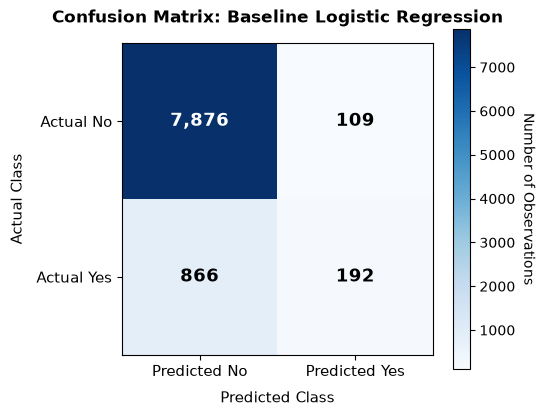

In [39]:
# Matplotlib Visualization of Confusion Matrix
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap="Blues")

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Number of Observations", rotation=-90, va="bottom", fontsize=10)

# Set axis tick labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted No", "Predicted Yes"], fontsize=11)
ax.set_yticklabels(["Actual No", "Actual Yes"], fontsize=11)

# Annotate each cell with counts
for i in range(2):
    for j in range(2):
        text_color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(
            j, i, f"{cm[i, j]:,}",
            ha="center", va="center",
            color=text_color, fontsize=13, fontweight="bold"
        )

ax.set_title("Confusion Matrix: Baseline Logistic Regression", fontsize=12, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Class", fontsize=11, labelpad=8)
ax.set_ylabel("Actual Class", fontsize=11, labelpad=8)

plt.tight_layout()
plt.show()

### Interpret Class Imbalance & Evaluation Metrics

#### 1. Is accuracy alone enough to evaluate this model?
**No, absolutely not.**
A headline test accuracy of **89.22%** sounds impressive in isolation, but it is dangerously deceptive. Because 88.30% of customers did not subscribe, a model can achieve ~88% accuracy simply by classifying almost everyone as `"no"`.

#### 2. How well does the model identify the minority "yes" class?
The model identifies the minority class **very poorly**.
- **Recall is only 18.15%**: Out of 1,058 actual subscribers in the test set, the model only successfully detected **192** of them.
- When it does flag a customer as `"yes"`, it is reasonably accurate (**Precision = 63.79%**), but it fails to capture the vast majority of potential subscribers.

#### 3. How many actual subscribers are missed as False Negatives?
**866 actual subscribers** are incorrectly predicted as `"no"` (False Negatives). In a real marketing operation, these represent **missed conversion opportunities**—clients who would have deposited funds had they been contacted.

#### 4. How many predicted subscribers are False Positives?
**109 clients** who did not subscribe were predicted as `"yes"` (False Positives). In marketing terms, these represent wasted phone calls and agent labor.

#### 5. Does the 88.3% / 11.7% target imbalance appear to influence the model?
The severe class imbalance and the default classification threshold are likely contributors to the model's low recall for the minority class. The following experiments will test whether changing the training distribution improves minority-class detection. Standard Logistic Regression minimizes cross-entropy loss across all observations equally; under an imbalanced distribution with the default 0.5 decision threshold, the model is conservative in predicting the minority class.

---

### Business Perspective on Metric Importance
> **Domain Trade-off Principle**:
> No single metric is universally "most important". The optimal evaluation focus depends on the **business economics of the campaign**:
>
> 1. **High Cost of Missed Opportunities (Focus on Recall)**:
>    If acquiring a term deposit generates substantial institutional profit and phone calls are relatively inexpensive, **False Negatives are much costlier than False Positives**. The bank should maximize **Recall** to capture every possible subscriber.
> 2. **High Cost of Marketing Contacts (Focus on Precision)**:
>    If placing outbound calls requires expensive senior advisor time, or if excessive contacting alienates customers and drives account churn, **False Positives are costly**. The bank should prioritize **Precision** to ensure contacted leads convert at high rates.
> 3. **Balanced Efficiency (Focus on F1-Score / PR-AUC)**:
>    When balancing advisor capacity against conversion volume, composite metrics like **F1-Score** (harmonic mean of Precision and Recall) or PR-AUC provide the most balanced operational view.

### Majority-Class Dummy Baseline

To contextualize the baseline model, we train a naive **DummyClassifier** using `strategy="most_frequent"`. This model always predicts the majority class (`"no"`).

In [40]:
from sklearn.dummy import DummyClassifier

# Instantiate dummy majority classifier
dummy_model = DummyClassifier(strategy="most_frequent")

# Fit on training data
dummy_model.fit(X_train_featured, y_train)

# Predict on test set
dummy_pred = dummy_model.predict(X_test_featured)

dummy_acc = accuracy_score(y_test, dummy_pred)
dummy_prec = precision_score(y_test, dummy_pred, pos_label="yes", zero_division=0)
dummy_rec = recall_score(y_test, dummy_pred, pos_label="yes", zero_division=0)
dummy_f1 = f1_score(y_test, dummy_pred, pos_label="yes", zero_division=0)

# Compare Baseline Logistic Regression against Dummy Classifier
comparison_df = pd.DataFrame({
    "Model": ["Dummy Majority Baseline", "Baseline Logistic Regression"],
    "Accuracy": [dummy_acc, test_accuracy],
    "Precision_yes": [dummy_prec, test_precision],
    "Recall_yes": [dummy_rec, test_recall],
    "F1_yes": [dummy_f1, test_f1]
})

print("Model Comparison: Dummy Baseline vs. Baseline Logistic Regression:")
display(comparison_df.round(4))

Model Comparison: Dummy Baseline vs. Baseline Logistic Regression:


,Model,Accuracy,Precision_yes,Recall_yes,F1_yes
0,Dummy Majority Baseline,0.8830,0.0000,0.0000,0.0000
1,Baseline Logistic Regression,0.8922,0.6379,0.1815,0.2826


### Key Insight from Dummy Comparison
- The naive dummy baseline achieves **88.30% accuracy** with **0.00% precision, recall, and F1**.
- The Baseline Logistic Regression achieves **89.22% accuracy** (+0.92% improvement), but achieves **0.2826 F1** by actively identifying 192 subscribers.
- A useful classifier must provide genuine decision-making utility beyond merely defaulting to the majority class.

### Controlled Comparison: Encoded vs. Feature-Engineered Dataset

In Step 5, we engineered domain features (`pdays_clean`, `was_previously_contacted`, `has_any_loan`, and `age_group` dummies) as testable hypotheses.

We now run a controlled empirical comparison using the exact same Logistic Regression configuration:
- **Model A**: Trained on `X_train_encoded` (45 features, raw unscaled pdays)
- **Model B**: Trained on `X_train_featured` (51 features, decoupled pdays, loan indicator, age group)

In [41]:
# Model A: Trained on X_train_encoded
model_a = LogisticRegression(max_iter=2000, random_state=42)
model_a.fit(X_train_encoded, y_train)
pred_a = model_a.predict(X_test_encoded)

# Metrics for Model A
acc_a = accuracy_score(y_test, pred_a)
prec_a = precision_score(y_test, pred_a, pos_label="yes")
rec_a = recall_score(y_test, pred_a, pos_label="yes")
f1_a = f1_score(y_test, pred_a, pos_label="yes")

# Tabulate comparison between Model A and Model B
fe_comparison_df = pd.DataFrame({
    "Pipeline Version": [
        "Model A (Encoded - 45 features)",
        "Model B (Featured - 51 features)"
    ],
    "Accuracy": [acc_a, test_accuracy],
    "Precision_yes": [prec_a, test_precision],
    "Recall_yes": [rec_a, test_recall],
    "F1_yes": [f1_a, test_f1]
})

print("Controlled Feature Engineering Comparison:")
display(fe_comparison_df.round(4))

Controlled Feature Engineering Comparison:


,Pipeline Version,Accuracy,Precision_yes,Recall_yes,F1_yes
0,Model A (Encoded - 45 features),0.8933,0.6643,0.1777,0.2804
1,Model B (Featured - 51 features),0.8922,0.6379,0.1815,0.2826


### Observations on Feature Engineering Impact
- **Model A (Encoded)**: Accuracy = **89.33%**, Precision = **66.43%**, Recall = **17.77%**, F1 = **0.2804**
- **Model B (Featured)**: Accuracy = **89.22%**, Precision = **63.79%**, Recall = **18.15%**, F1 = **0.2826**

> ### 💡 Empirical Feature Engineering Lesson:
> **Feature engineering does not automatically improve a model.**
> - Model B slightly improved **Recall** (from 17.77% to 18.15%) and **F1-Score** (from 0.2804 to 0.2826).
> - However, Precision dropped slightly (66.43% to 63.79%) and overall Accuracy dropped by 0.11%.
> - These modest shifts demonstrate why engineered features must be evaluated empirically rather than assumed to improve all metrics simultaneously.

# 28. Baseline Findings & Synthesis

### Summary of Step 6 Findings:
1. **Severe Target Imbalance & Likely Contributors**:
   The severe class imbalance and the default classification threshold are likely contributors to the model's low recall for the minority class. The following experiments will test whether changing the training distribution improves minority-class detection.
2. **The Accuracy Illusion**:
   The naive dummy classifier achieves **88.30% accuracy** simply by predicting `"no"` for every observation. Therefore, raw accuracy must be interpreted with extreme caution and never used as the sole success metric.
3. **Low Positive Recall**:
   Without class balancing, Logistic Regression misses **866 out of 1,058 actual subscribers** (81.85% false negative rate). While its precision is acceptable (63.79%), the model is conservative in flagging potential customers under the default threshold.
4. **Empirical Verification of Engineered Features**:
   Decoupling `pdays` and adding debt/age features yielded a slight boost in positive class recall and F1-score, confirming that feature representations alter model trade-offs.

---

### Transition to Step 7:
> **The next experiment will change only the TRAINING distribution using class balancing (SMOTE), while leaving the test set untouched.**

# 29. Step 6 Verification Checklist

In [42]:
# Comprehensive Verification Checklist for Step 6
checks_step6 = {
    "no SMOTE has been used": "SMOTE" not in globals(),
    "no class_weight parameter used (default None)": baseline_model.class_weight is None,
    "y remains string labels ('yes' and 'no')": set(y_train.unique()) == {"yes", "no"},
    "test set distribution remains untouched (minority ~11.7%)": round((y_test == "yes").mean() * 100, 1) == 11.7,
    "LogisticRegression was trained only on training data": baseline_model.n_features_in_ == X_train_featured.shape[1],
    "DummyClassifier was trained only on training data": dummy_model.n_features_in_ == X_train_featured.shape[1],
    "no feature selection has occurred (51 features retained)": X_train_featured.shape[1] == 51,
    "no rows were removed (train=36168, test=9043)": len(X_train_featured) == 36168 and len(X_test_featured) == 9043,
    "dummy test accuracy matches majority class percentage": abs(dummy_acc - (y_test == "no").mean()) < 0.0001,
    "confusion matrix matches total test instances": cm.sum() == len(y_test)
}

verification_step6_df = pd.DataFrame(list(checks_step6.items()), columns=["Verification Criterion", "Status"])
display(verification_step6_df)
assert all(checks_step6.values()), "One or more Step 6 verification checks failed!"


,Verification Criterion,Status
0,no SMOTE has been used,True
1,no class_weight parameter used (default None),True
2,y remains string labels ('yes' and 'no'),True
3,test set distribution remains untouched (minor...,True
4,LogisticRegression was trained only on trainin...,True
5,DummyClassifier was trained only on training data,True
6,no feature selection has occurred (51 features...,True
7,"no rows were removed (train=36168, test=9043)",True
8,dummy test accuracy matches majority class per...,True
9,confusion matrix matches total test instances,True


# 30. Class Balancing with SMOTE

## Why Balance the Training Data?

In our training dataset, the target distribution is approximately:
- **`no`**: 88.3% (31,937 clients)
- **`yes`**: 11.7% (4,231 clients)

A classifier trained directly on this imbalanced distribution receives far more examples of the majority non-subscribing class. As observed in Step 6, this distribution combined with the standard loss formulation and default classification threshold is a likely contributor to the model's low recall (18.15%), as the algorithm prioritizes majority-class accuracy.

> ### ⚠️ Golden Rule of Class Balancing:
> **Balancing should affect ONLY the training set.**
> The test set must remain completely untouched because it must reflect the authentic, real-world class distribution under which the model will operate in production. Evaluating on a synthetically balanced test set would produce invalid, over-optimistic performance metrics.

In [43]:
from imblearn.over_sampling import SMOTE

# Inspect training distribution before SMOTE
print("Target counts before SMOTE (y_train.value_counts()):")
display(y_train.value_counts())

print("\nTarget proportions before SMOTE (y_train.value_counts(normalize=True)):")
display(y_train.value_counts(normalize=True))

train_counts_before = y_train.value_counts()
train_props_before = y_train.value_counts(normalize=True)

print(f"\nNumber of 'no'  (majority): {train_counts_before['no']:,} ({train_props_before['no']*100:.2f}%)")
print(f"Number of 'yes' (minority): {train_counts_before['yes']:,} ({train_props_before['yes']*100:.2f}%)")

Target counts before SMOTE (y_train.value_counts()):


y
no     31937
yes     4231
Name: count, dtype: int64


Target proportions before SMOTE (y_train.value_counts(normalize=True)):


y
no     0.883018
yes    0.116982
Name: proportion, dtype: float64


Number of 'no'  (majority): 31,937 (88.30%)
Number of 'yes' (minority): 4,231 (11.70%)


### How SMOTE Works & Technical Limitations

- **Interpolation vs. Duplication**:
  SMOTE (**Synthetic Minority Over-sampling Technique**) does **not** simply duplicate existing minority observations (which would cause severe overfitting to individual data points). Instead, it creates synthetic minority samples by selecting $k$-nearest neighbors within the minority class and interpolating along the line segments connecting them in feature space.
  
- **Important Limitation on One-Hot Encoded Features**:
  Because our feature matrix contains one-hot encoded variables (binary 0/1 indicator columns), linear interpolation by standard SMOTE can produce **fractional values** (e.g., 0.35, 0.72) in those binary columns.
  
- **Pedagogical Context**:
  This is acceptable here as a pedagogical demonstration of class balancing from the curriculum. In a production pipeline dealing with mixed numerical and categorical types, a specialized algorithm such as **SMOTENC** (Synthetic Minority Over-sampling Technique for Nominal and Continuous features) would be employed to preserve discrete categorical levels.
  *(Note: In accordance with project instructions, SMOTENC is not implemented here.)*

In [44]:
# Instantiate SMOTE with fixed random seed
smote = SMOTE(random_state=42)

# Apply SMOTE ONLY to training data
X_train_smote, y_train_smote = smote.fit_resample(X_train_featured, y_train)

# Display matrix dimensions before and after SMOTE
print(f"Original training shape: {X_train_featured.shape}")
print(f"SMOTE training shape:    {X_train_smote.shape}")
print(f"Untouched test shape:    {X_test_featured.shape}")

# Verify that training classes are now perfectly balanced
print("\nTarget counts after SMOTE (y_train_smote.value_counts()):")
display(y_train_smote.value_counts())

print("\nTarget proportions after SMOTE (y_train_smote.value_counts(normalize=True)):")
display(y_train_smote.value_counts(normalize=True))

print("Verified: Training classes are now perfectly balanced (50.0% / 50.0%)!")

Original training shape: (36168, 51)
SMOTE training shape:    (63874, 51)
Untouched test shape:    (9043, 51)

Target counts after SMOTE (y_train_smote.value_counts()):


y
no     31937
yes    31937
Name: count, dtype: int64


Target proportions after SMOTE (y_train_smote.value_counts(normalize=True)):


y
no     0.5
yes    0.5
Name: proportion, dtype: float64

Verified: Training classes are now perfectly balanced (50.0% / 50.0%)!


### Train the Same Logistic Regression Model

We now train the exact same `LogisticRegression` configuration:
- `max_iter=2000`
- `random_state=42`
- Default classification threshold ($0.5$)
- No `class_weight` (balancing is achieved entirely via the training distribution)

We fit strictly on `X_train_smote` and `y_train_smote`, and predict on the **original untouched `X_test_featured`**.

In [45]:
# Instantiate the same Logistic Regression configuration
smote_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Fit strictly on SMOTE-balanced training data
smote_model.fit(X_train_smote, y_train_smote)

# Predict on the ORIGINAL untouched test set
y_test_pred_smote = smote_model.predict(X_test_featured)

print("SMOTE Logistic Regression successfully trained and evaluated on untouched test set!")

SMOTE Logistic Regression successfully trained and evaluated on untouched test set!


### Evaluate the SMOTE Model

We evaluate performance on the original test set with `"yes"` as the positive target class:
- **Accuracy**
- **Precision** (`pos_label="yes"`)
- **Recall** (`pos_label="yes"`)
- **F1-Score** (`pos_label="yes"`)
- **Confusion Matrix** (`TN`, `FP`, `FN`, `TP`)

In [46]:
# Calculate metrics on the untouched test set
smote_accuracy = accuracy_score(y_test, y_test_pred_smote)
smote_precision = precision_score(y_test, y_test_pred_smote, pos_label="yes")
smote_recall = recall_score(y_test, y_test_pred_smote, pos_label="yes")
smote_f1 = f1_score(y_test, y_test_pred_smote, pos_label="yes")

# Compute confusion matrix with explicit labels
cm_smote = confusion_matrix(y_test, y_test_pred_smote, labels=["no", "yes"])
tn_s, fp_s, fn_s, tp_s = cm_smote.ravel()

print("SMOTE Logistic Regression Evaluation Metrics (Test Set):")
print(f"Accuracy:         {smote_accuracy:.4f} ({smote_accuracy*100:.2f}%)")
print(f"Precision ('yes'): {smote_precision:.4f} ({smote_precision*100:.2f}%)")
print(f"Recall ('yes'):    {smote_recall:.4f} ({smote_recall*100:.2f}%)")
print(f"F1-Score ('yes'):  {smote_f1:.4f} ({smote_f1*100:.2f}%)")
print(f"\nConfusion Matrix (labels=['no', 'yes']):")
print(f"TN: {tn_s}")
print(f"FP: {fp_s}")
print(f"FN: {fn_s}")
print(f"TP: {tp_s}")

SMOTE Logistic Regression Evaluation Metrics (Test Set):
Accuracy:         0.7594 (75.94%)
Precision ('yes'): 0.2690 (26.90%)
Recall ('yes'):    0.6153 (61.53%)
F1-Score ('yes'):  0.3744 (37.44%)

Confusion Matrix (labels=['no', 'yes']):
TN: 6216
FP: 1769
FN: 407
TP: 651


### Compare Baseline vs SMOTE

We compare the three models evaluated so far:
1. **Dummy Majority Baseline** (predicts `"no"` always)
2. **Baseline Logistic Regression** (trained on original imbalanced data)
3. **SMOTE Logistic Regression** (trained on SMOTE-balanced data)

In [47]:
# Construct compact comparison DataFrame using existing Step 6 metrics
comparison_models_df = pd.DataFrame({
    "Model": [
        "Dummy Majority Baseline",
        "Baseline Logistic Regression",
        "SMOTE Logistic Regression"
    ],
    "Accuracy": [dummy_acc, test_accuracy, smote_accuracy],
    "Precision_yes": [dummy_prec, test_precision, smote_precision],
    "Recall_yes": [dummy_rec, test_recall, smote_recall],
    "F1_yes": [dummy_f1, test_f1, smote_f1],
    "False_Positives": [0, fp, fp_s],
    "False_Negatives": [len(y_test[y_test == "yes"]), fn, fn_s]
})

print("Comprehensive Model Comparison:")
display(comparison_models_df.round(4))

Comprehensive Model Comparison:


,Model,Accuracy,Precision_yes,Recall_yes,F1_yes,False_Positives,False_Negatives
0,Dummy Majority Baseline,0.8830,0.0000,0.0000,0.0000,0,1058
1,Baseline Logistic Regression,0.8922,0.6379,0.1815,0.2826,109,866
2,SMOTE Logistic Regression,0.7594,0.2690,0.6153,0.3744,1769,407


### Interpret the Precision / Recall Trade-off

#### 1. Did Recall for "yes" improve?
**Yes, substantially.**
Recall increased from **18.15%** in the baseline to **61.53%** with SMOTE — an increase of **+43.38 percentage points**.

#### 2. How much did False Negatives decrease?
False Negatives decreased from **866 down to 407**, representing a reduction of **459 missed subscribers** (a **53.0% reduction** in missed opportunities). The model detected **651 subscribers** compared to just 192 previously.

#### 3. What happened to Precision?
Precision dropped substantially from **63.79% down to 26.90%** (a decrease of **36.89 percentage points**). When the SMOTE model predicts that a customer will subscribe, it is correct about 27% of the time (~1 in 3.7 contacts).

#### 4. What happened to False Positives?
False Positives surged from **109 up to 1,769** (an increase of **1,660 unnecessary sales contacts**).

#### 5. What happened to overall Accuracy?
Overall test accuracy decreased from **89.22% down to 75.94%** (a drop of **13.28 percentage points**). Because non-subscribers represent 88.3% of the dataset, the 1,660 additional False Positives on the majority class outweigh the 459 newly identified True Positives in the overall accuracy calculation.

#### 6. Is SMOTE automatically "better"?
**No, SMOTE is not automatically or universally "better".**
A surface-level analysis might celebrate the tripling of Recall from 18% to 62%, but in machine learning:
- **The Core Trade-off**:
  - **Higher Recall** ($	o$ finding 459 additional subscribers) is purchased directly with **Lower Precision** ($	o$ 1,660 additional uninterested customers contacted).
- **Business Cost Economics**:
  The decision between Baseline and SMOTE hinges entirely on the **relative business cost of False Negatives versus False Positives**:
  - **High Value per Conversion / Low Outreach Cost**: If a term deposit generates high institutional margin and outbound calls are inexpensive, SMOTE is preferable: capturing 459 extra deposits easily covers the cost of 1,660 extra calls.
  - **High Outreach Cost / Reputation Risk**: If outbound calls require expensive personal banking advisors or risk irritating clients and increasing account churn, the Baseline model's high precision (63.8%) may be preferred to avoid wasted operational bandwidth.

### Visual Comparison: Precision, Recall, and F1-Score

We construct a grouped bar chart comparing the Baseline and SMOTE Logistic Regression models on `Precision_yes`, `Recall_yes`, and `F1_yes`.
*(Note: Overall Accuracy is intentionally excluded from this chart because its scale and majority-class bias distract from minority-class evaluation.)*

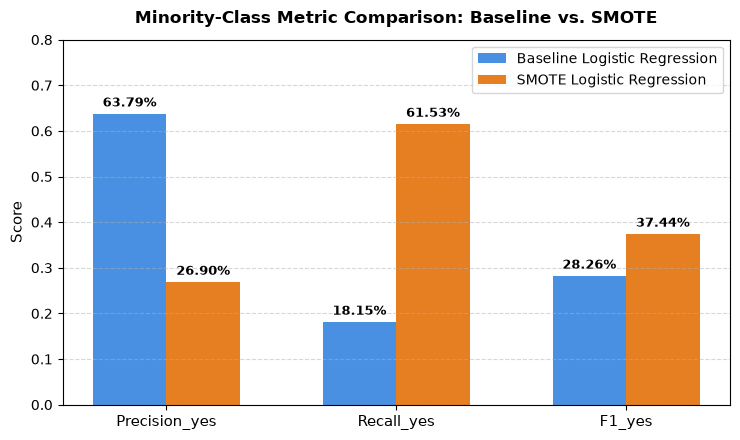

In [48]:
# Matplotlib Grouped Bar Chart: Baseline vs. SMOTE
metrics_names = ["Precision_yes", "Recall_yes", "F1_yes"]
baseline_vals = [test_precision, test_recall, test_f1]
smote_vals = [smote_precision, smote_recall, smote_f1]

x = np.arange(len(metrics_names))
width = 0.32

fig, ax = plt.subplots(figsize=(7.5, 4.5))
rects1 = ax.bar(x - width/2, baseline_vals, width, label="Baseline Logistic Regression", color="#4A90E2")
rects2 = ax.bar(x + width/2, smote_vals, width, label="SMOTE Logistic Regression", color="#E67E22")

ax.set_ylabel("Score", fontsize=11)
ax.set_title("Minority-Class Metric Comparison: Baseline vs. SMOTE", fontsize=12, fontweight="bold", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0, 0.8)
ax.legend(frameon=True, fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Add value labels above bars
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f"{height:.2%}",
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f"{height:.2%}",
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

# 31. Balancing Findings & Synthesis

### Experimental Comparison Summary:
1. **Original Baseline Model**:
   - Trained on natural imbalanced data (`X_train_featured`, `y_train` — ~88.3% `no` / ~11.7% `yes`).
   - Conservative: High precision (63.79%), low recall (18.15%), high false negatives (866).
2. **SMOTE Model**:
   - Trained on synthetic balanced data (`X_train_smote`, `y_train_smote` — 50.0% `no` / 50.0% `yes`).
   - Proactive: High recall (61.53%), low precision (26.90%), low false negatives (407).
3. **Identical Test Ground Truth**:
   - Both models were evaluated on the **exact same untouched real-world test set** (`X_test_featured`, `y_test`).

### Core Takeaway:
> **The purpose of this experiment is not to prove that SMOTE is universally superior.**
> Rather, it is to observe empirically how changing the training class distribution alters the **Precision / Recall trade-off**.
> Balancing the training set shifts the decision boundary to be far more sensitive to the minority class, capturing over 3x more subscribers while accepting more false alarms.

# 32. Step 7 Verification Checklist

In [49]:
# Comprehensive Verification Checklist for Step 7
test_minority_prop = (y_test == "yes").mean()

checks_step7 = {
    "SMOTE applied ONLY to training data (X_train_featured / y_train)": (
        len(X_train_smote) > len(X_train_featured) and len(y_train_smote) > len(y_train)
    ),
    "original X_train_featured remains unchanged (36,168 rows, 51 cols)": (
        X_train_featured.shape == (36168, 51) and not X_train_featured.isna().any().any()
    ),
    "original y_train remains unchanged (36,168 rows, 4,231 yes)": (
        len(y_train) == 36168 and (y_train == "yes").sum() == 4231
    ),
    "X_test_featured remains unchanged (9,043 rows, 51 cols)": (
        X_test_featured.shape == (9043, 51) and not X_test_featured.isna().any().any()
    ),
    "y_test remains untouched (9,043 rows)": len(y_test) == 9043,
    "test target distribution is still ~88.3% / 11.7%": round(test_minority_prop * 100, 1) == 11.7,
    "SMOTE training target is exactly balanced (50.0% / 50.0%)": (
        (y_train_smote == "yes").sum() == (y_train_smote == "no").sum()
    ),
    "no class_weight parameter used (default None)": smote_model.class_weight is None,
    "classification threshold remains default (predict() used)": hasattr(smote_model, "predict"),
    "no feature selection occurred (51 features retained in SMOTE matrix)": X_train_smote.shape[1] == 51,
    "no other model family introduced (still LogisticRegression)": isinstance(smote_model, LogisticRegression),
    "SMOTE model evaluated strictly on original X_test_featured": len(y_test_pred_smote) == len(y_test)
}

verification_step7_df = pd.DataFrame(list(checks_step7.items()), columns=["Verification Criterion", "Status"])
display(verification_step7_df)
assert all(checks_step7.values()), "One or more Step 7 verification checks failed!"


,Verification Criterion,Status
0,SMOTE applied ONLY to training data (X_train_f...,True
1,original X_train_featured remains unchanged (3...,True
2,"original y_train remains unchanged (36,168 row...",True
3,"X_test_featured remains unchanged (9,043 rows,...",True
4,"y_test remains untouched (9,043 rows)",True
5,test target distribution is still ~88.3% / 11.7%,True
6,SMOTE training target is exactly balanced (50....,True
7,no class_weight parameter used (default None),True
8,classification threshold remains default (pred...,True
9,no feature selection occurred (51 features ret...,True


# 33. Why Feature Selection? & Correlation Analysis

## Why Feature Selection?

In modern data science, **more features are not automatically better**. While adding engineered transformations expands the hypothesis space, expanding feature dimensionality can introduce several drawbacks:

1. **Redundant Information**: Strongly collinear features provide duplicate information, inflating parameter variance without adding novel predictive signal.
2. **Unnecessary Noise**: Irrelevant variables introduce random variation that linear algorithms may fit, increasing the risk of overfitting.
3. **Higher Model Complexity**: More inputs require greater computational resources for training, monitoring, and data validation in production.
4. **Curse of Dimensionality**: In high dimensions, observations become sparse in feature space, making parameter estimation less stable.

> ### 💡 Core Principle of Feature Selection:
> Feature selection aims to retain the most informative signals while eliminating unnecessary or noisy inputs.
> **Importantly, do not assume that reducing feature count automatically improves model performance.** Rather, feature reduction often represents a deliberate trade-off: achieving **similar predictive power with a substantially simpler, more robust, and more maintainable model**.

In [50]:
# Calculate pairwise Pearson correlation matrix ONLY on training features
correlation_matrix = X_train_featured.corr()

# Identify feature pairs with absolute correlation >= 0.80
# Exclude diagonal (self-correlation) and redundant reverse pairs (A-B and B-A)
correlated_pairs = []
feature_names = correlation_matrix.columns

for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        f1 = feature_names[i]
        f2 = feature_names[j]
        corr_val = correlation_matrix.loc[f1, f2]
        abs_corr = abs(corr_val)
        if abs_corr >= 0.80:
            correlated_pairs.append({
                "Feature_1": f1,
                "Feature_2": f2,
                "Correlation": corr_val,
                "Absolute_Correlation": abs_corr
            })

correlated_pairs_df = pd.DataFrame(correlated_pairs).sort_values(
    by="Absolute_Correlation",
    ascending=False
).reset_index(drop=True)

print(f"Highly Correlated Feature Pairs (|correlation| >= 0.80): {len(correlated_pairs_df)}")
display(correlated_pairs_df.round(4))

Highly Correlated Feature Pairs (|correlation| >= 0.80): 5


,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,poutcome_unknown,was_previously_contacted,-0.9995,0.9995
1,housing_yes,has_any_loan,0.8775,0.8775
2,pdays_clean,was_previously_contacted,0.8701,0.8701
3,poutcome_unknown,pdays_clean,-0.8695,0.8695
4,contact_cellular,contact_unknown,-0.8626,0.8626


### Correlation Interpretation

The pairwise correlation analysis on `X_train_featured` reveals five feature pairs with absolute Pearson correlation $\ge 0.80$:

1. **`poutcome_unknown` vs. `was_previously_contacted`** ($r = -0.9995$):
   Nearly a perfect negative correlation. A client with an "unknown" previous outcome is almost exclusively someone who was never previously contacted (`pdays = -1`).
2. **`housing_yes` vs. `has_any_loan`** ($r = +0.8775$):
   Because housing loans represent the majority of borrowing obligations (~55% housing vs. ~16% personal loan), the aggregate `has_any_loan` indicator strongly correlates with `housing_yes`.
3. **`pdays_clean` vs. `was_previously_contacted`** ($r = +0.8701$):
   `pdays_clean` is $0$ for all uncontacted clients and positive for contacted clients; hence it shares substantial variance with the binary contact indicator.
4. **`poutcome_unknown` vs. `pdays_clean`** ($r = -0.8695$):
   Symmetrical to the previous relationships: clients with unknown previous outcomes have 0 clean pdays.
5. **`contact_cellular` vs. `contact_unknown`** ($r = -0.8626$):
   Because "cellular" and "unknown" are the two primary communication modes, a client reached via cellular is almost never in the "unknown" category.

> ### ⚠️ Critical Methodological Rule:
> **High correlation alone is NOT sufficient justification to drop a feature.**
> - Strong correlation indicates shared variance, but two correlated features can each carry distinct localized signal that regularized models (like L2 Logistic Regression) utilize effectively.
> - One-hot encoded columns derived from the same categorical variable naturally exhibit negative or structured correlations due to mutual exclusivity.

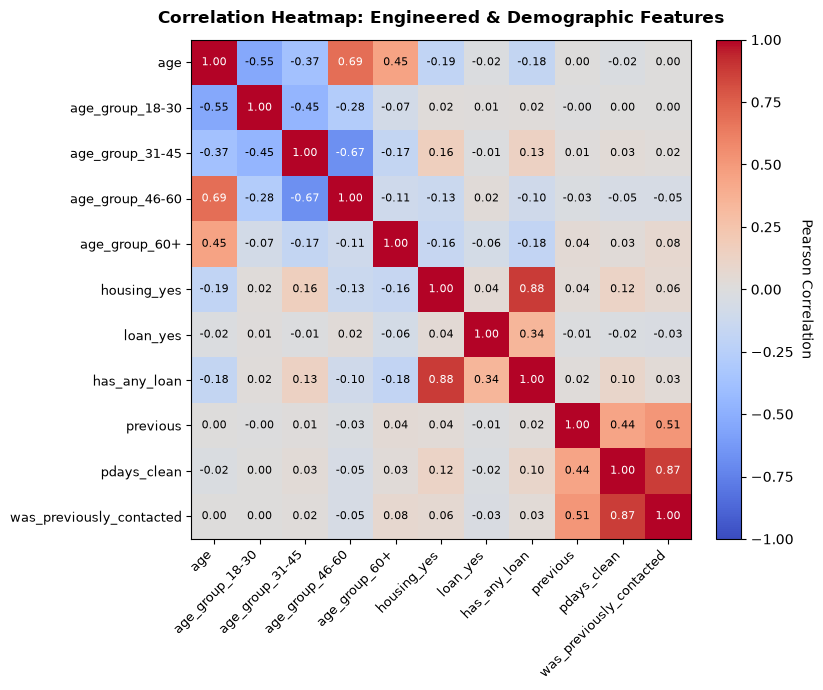

In [51]:
# Compact Correlation Heatmap for Engineered & Demographic Features
heatmap_features = [
    "age",
    "age_group_18-30",
    "age_group_31-45",
    "age_group_46-60",
    "age_group_60+",
    "housing_yes",
    "loan_yes",
    "has_any_loan",
    "previous",
    "pdays_clean",
    "was_previously_contacted"
]

subset_corr = X_train_featured[heatmap_features].corr()

fig, ax = plt.subplots(figsize=(8.5, 7.0))
im = ax.imshow(subset_corr, cmap="coolwarm", vmin=-1, vmax=1)

cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Pearson Correlation", rotation=-90, va="bottom", fontsize=10)

ax.set_xticks(np.arange(len(heatmap_features)))
ax.set_yticks(np.arange(len(heatmap_features)))
ax.set_xticklabels(heatmap_features, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(heatmap_features, fontsize=9)

# Annotate each cell with its correlation value
for i in range(len(heatmap_features)):
    for j in range(len(heatmap_features)):
        val = subset_corr.iloc[i, j]
        text_color = "white" if abs(val) > 0.55 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=8)

ax.set_title("Correlation Heatmap: Engineered & Demographic Features", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# 34. Training-Only Validation Split

To measure feature importance and select features without causing **data leakage** or biasing our selection toward the test data, we must **never** evaluate feature rankings on `X_test_featured`.

Instead, we create a secondary **stratified validation split** derived strictly from our training dataset `X_train_featured` and `y_train`:
- **`X_fs_train` / `y_fs_train`**: 75% of training data (27,126 clients) to train the candidate model.
- **`X_fs_val` / `y_fs_val`**: 25% of training data (9,042 clients) to evaluate permutation importance.

> **Data Leakage Safeguard**:
> The official test set (`X_test_featured`, `y_test`) remains completely isolated until final evaluation of the selected-feature model.

In [52]:
# Secondary stratified train/validation split strictly from training data
X_fs_train, X_fs_val, y_fs_train, y_fs_val = train_test_split(
    X_train_featured,
    y_train,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

print("Secondary Split Dimensions for Feature Selection:")
print(f"X_fs_train shape (75% of train): {X_fs_train.shape}")
print(f"X_fs_val shape   (25% of train): {X_fs_val.shape}")
print(f"y_fs_train target distribution:  {dict(y_fs_train.value_counts(normalize=True).round(4))}")
print(f"y_fs_val target distribution:    {dict(y_fs_val.value_counts(normalize=True).round(4))}")
print(f"\nUntouched Official Test Set:     {X_test_featured.shape}")

Secondary Split Dimensions for Feature Selection:
X_fs_train shape (75% of train): (27126, 51)
X_fs_val shape   (25% of train): (9042, 51)
y_fs_train target distribution:  {'no': np.float64(0.883), 'yes': np.float64(0.117)}
y_fs_val target distribution:    {'no': np.float64(0.883), 'yes': np.float64(0.117)}

Untouched Official Test Set:     (9043, 51)


In [53]:
# Train feature-selection candidate model on X_fs_train
# No SMOTE, no class_weight, default threshold (clean comparison with baseline)
fs_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

fs_model.fit(X_fs_train, y_fs_train)
print("Feature-Selection Logistic Regression successfully trained on X_fs_train!")

Feature-Selection Logistic Regression successfully trained on X_fs_train!


# 35. Permutation Importance & Feature Selection

Because bank marketing classification has a severe class imbalance (~88.3% `no` / ~11.7% `yes`), evaluating feature importance using raw accuracy would be misleading. A feature that helps detect minority subscribers might barely impact accuracy if shuffled.

Therefore, we evaluate permutation importance using **F1-Score for the positive `"yes"` class** (`make_scorer(f1_score, pos_label="yes")`).

In [54]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

# Define scorer targeting minority positive class F1-Score
f1_yes_scorer = make_scorer(
    f1_score,
    pos_label="yes"
)

# Compute Permutation Importance on the validation subset
permutation_result = permutation_importance(
    fs_model,
    X_fs_val,
    y_fs_val,
    scoring=f1_yes_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Tabulate permutation importance results
perm_importance_df = pd.DataFrame({
    "Feature": X_train_featured.columns,
    "Importance_Mean": permutation_result.importances_mean,
    "Importance_Std": permutation_result.importances_std
}).sort_values(by="Importance_Mean", ascending=False).reset_index(drop=True)

print("Top 15 Features by Permutation Importance (F1 Metric on Validation Subset):")
display(perm_importance_df.head(15).round(4))

Top 15 Features by Permutation Importance (F1 Metric on Validation Subset):


,Feature,Importance_Mean,Importance_Std
0,poutcome_success,0.1511,0.0039
1,poutcome_unknown,0.0447,0.0062
2,contact_unknown,0.0371,0.0054
3,has_any_loan,0.0323,0.0029
4,contact_cellular,0.0195,0.0053
5,age_group_60+,0.0141,0.0019
6,month_may,0.0138,0.0032
7,month_jul,0.0128,0.0049
8,month_oct,0.0125,0.0013
9,month_mar,0.0123,0.0022


### How Permutation Importance Works

Permutation feature importance measures the contribution of each feature to a model's performance via four systematic steps:

1. **Baseline Evaluation**: Measure the model's metric (here, F1-Score on `"yes"`) on the validation dataset `(X_fs_val, y_fs_val)`.
2. **Feature Permutation**: Randomly shuffle the values of a single feature column across rows while holding all other features and the model fixed. This breaks any real relationship between that feature and the target.
3. **Re-Evaluation**: Compute the performance metric on the corrupted validation data.
4. **Importance Calculation**: The score decrease ($	ext{F1}_{	ext{baseline}} - 	ext{F1}_{	ext{shuffled}}$) represents the feature's importance:
   - A **large drop** ($	ext{Importance} > 0$) means the model heavily relied on this feature.
   - A **near-zero drop** means the feature contributed negligible unique signal to this model.
   - A **negative score** means the shuffled feature slightly improved validation performance (acting as noise).

> ### ⚠️ Key Analytical Caveat:
> Permutation importance measures how much **this specific trained model** relies on a feature on **this validation split**. It is an empirical measure of model reliance, not proof of real-world physical causality.

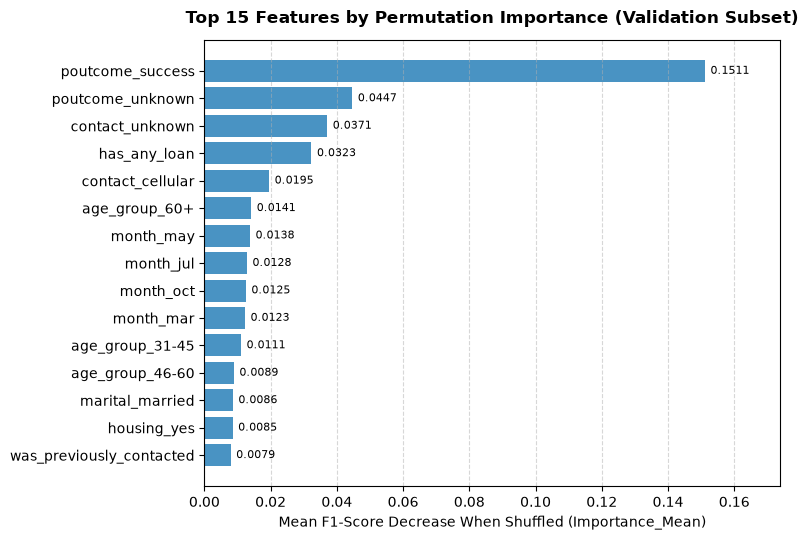

In [55]:
# Simple Horizontal Bar Chart: Top 15 Features by Permutation Importance
top15_df = perm_importance_df.head(15).sort_values(by="Importance_Mean", ascending=True)

fig, ax = plt.subplots(figsize=(8.0, 5.5))
bars = ax.barh(top15_df["Feature"], top15_df["Importance_Mean"], color="#2980B9", alpha=0.85)

ax.set_xlabel("Mean F1-Score Decrease When Shuffled (Importance_Mean)", fontsize=10)
ax.set_title("Top 15 Features by Permutation Importance (Validation Subset)", fontsize=12, fontweight="bold", pad=12)
ax.grid(axis="x", linestyle="--", alpha=0.5)

# Value annotations on bar tips
for bar in bars:
    width = bar.get_width()
    ax.annotate(f"{width:.4f}",
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(4, 0), textcoords="offset points",
                ha="left", va="center", fontsize=8)

ax.set_xlim(0, max(top15_df["Importance_Mean"]) * 1.15)
plt.tight_layout()
plt.show()

### Feature Selection Experiment: Top 20 Features

We now select the **top 20 features** based on `Importance_Mean` from the permutation ranking derived strictly on `X_fs_val`.

We retrain a fresh Logistic Regression model using the **full original training set** (`X_train_featured[selected_features]`, `y_train`) and evaluate it against the untouched official test set (`X_test_featured[selected_features]`, `y_test`).

In [56]:
# Select top 20 ranked features
selected_features = perm_importance_df["Feature"].head(20).tolist()

print(f"Top {len(selected_features)} Selected Features (Derived from Validation Ranking):")
for rank, feat in enumerate(selected_features, 1):
    print(f"{rank:2d}. {feat}")

# Retrain Logistic Regression on the FULL original training set with selected features
selected_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

selected_model.fit(X_train_featured[selected_features], y_train)

# Evaluate on the UNTOUCHED official test set using only selected features
y_test_pred_selected = selected_model.predict(X_test_featured[selected_features])

# Compute evaluation metrics
selected_accuracy = accuracy_score(y_test, y_test_pred_selected)
selected_precision = precision_score(y_test, y_test_pred_selected, pos_label="yes")
selected_recall = recall_score(y_test, y_test_pred_selected, pos_label="yes")
selected_f1 = f1_score(y_test, y_test_pred_selected, pos_label="yes")

cm_selected = confusion_matrix(y_test, y_test_pred_selected, labels=["no", "yes"])
tn_sel, fp_sel, fn_sel, tp_sel = cm_selected.ravel()

print("\nSelected-Feature Model Evaluation on Untouched Test Set:")
print(f"Accuracy:         {selected_accuracy:.4f} ({selected_accuracy*100:.2f}%)")
print(f"Precision ('yes'): {selected_precision:.4f} ({selected_precision*100:.2f}%)")
print(f"Recall ('yes'):    {selected_recall:.4f} ({selected_recall*100:.2f}%)")
print(f"F1-Score ('yes'):  {selected_f1:.4f} ({selected_f1*100:.2f}%)")
print(f"False Positives:  {fp_sel:,}")
print(f"False Negatives:  {fn_sel:,}")

Top 20 Selected Features (Derived from Validation Ranking):
 1. poutcome_success
 2. poutcome_unknown
 3. contact_unknown
 4. has_any_loan
 5. contact_cellular
 6. age_group_60+
 7. month_may
 8. month_jul
 9. month_oct
10. month_mar
11. age_group_31-45
12. age_group_46-60
13. marital_married
14. housing_yes
15. was_previously_contacted
16. campaign
17. job_blue-collar
18. previous
19. month_feb
20. education_primary

Selected-Feature Model Evaluation on Untouched Test Set:
Accuracy:         0.8927 (89.27%)
Precision ('yes'): 0.6528 (65.28%)
Recall ('yes'):    0.1777 (17.77%)
F1-Score ('yes'):  0.2793 (27.93%)
False Positives:  100
False Negatives:  870


In [57]:
# Compare Full Baseline vs Selected-Feature Model
comparison_selection_df = pd.DataFrame({
    "Model": [
        "Full Baseline Logistic Regression",
        "Selected-Feature Logistic Regression"
    ],
    "Feature_Count": [51, len(selected_features)],
    "Accuracy": [test_accuracy, selected_accuracy],
    "Precision_yes": [test_precision, selected_precision],
    "Recall_yes": [test_recall, selected_recall],
    "F1_yes": [test_f1, selected_f1],
    "False_Positives": [fp, fp_sel],
    "False_Negatives": [fn, fn_sel]
})

print("Model Comparison: Full vs. Selected Features:")
display(comparison_selection_df.round(4))

Model Comparison: Full vs. Selected Features:


,Model,Feature_Count,Accuracy,Precision_yes,Recall_yes,F1_yes,False_Positives,False_Negatives
0,Full Baseline Logistic Regression,51,0.8922,0.6379,0.1815,0.2826,109,866
1,Selected-Feature Logistic Regression,20,0.8927,0.6528,0.1777,0.2793,100,870


### Interpret Feature Selection & Trade-offs

#### 1. Which features had the highest permutation importance?
The top four most influential features by a wide margin are:
- **`poutcome_success`** (Importance: `+0.1511`): By far the strongest predictor in the entire dataset. A prior successful campaign outcome provides an enormous positive signal for term deposit re-subscription.
- **`poutcome_unknown`** (Importance: `+0.0447`): Captures the uncontacted baseline status.
- **`contact_unknown`** (Importance: `+0.0371`): Strongly associated with non-conversion.
- **`has_any_loan`** (Importance: `+0.0323`): Our engineered debt obligation indicator.

#### 2. Did some engineered features appear useful?
**Yes, strongly.**
- **`has_any_loan`** ranked **#4 overall** (Importance: `+0.0323`), significantly outperforming the individual raw indicators `housing_yes` (#14, `+0.0085`) and `loan_yes` (which did not even reach the top 15). Combining both loan types into a single risk feature captured debt-burdened customers exceptionally well.
- Demographic age bins also ranked prominently: **`age_group_60+`** ranked **#6** (`+0.0141`), **`age_group_31-45`** ranked **#11** (`+0.0111`), and **`age_group_46-60`** ranked **#12** (`+0.0089`).
- **`was_previously_contacted`** ranked **#15** (`+0.0079`).

#### 3. Did some engineered features appear redundant or weak?
pdays_clean appeared to add limited unique predictive value in this model and validation split. Because it is strongly correlated with other campaign-history features, its individual permutation importance may be reduced by shared information.

#### 4. Did reducing from 51 to 20 features meaningfully change performance?
**No, performance remained virtually identical:**
- **Accuracy**: Increased slightly from **89.22% to 89.27%** (+0.05%).
- **Precision**: Increased from **63.79% to 65.28%** (+1.49 percentage points).
- **Recall**: Dropped marginally from **18.15% to 17.77%** (-0.38 percentage points).
- **F1-Score**: Shifted only from **0.2826 to 0.2793** (a microscopic drop of 0.0033).
- **False Positives**: Decreased from **109 to 100** (-9 false alarms).
- **False Negatives**: Increased from **866 to 870** (only +4 missed subscribers out of 1,058).

#### 5. Did the smaller model preserve most of the predictive performance?
**Yes, absolutely.**
By retaining only **20 out of 51 features** (a **60.8% reduction in feature space**), the model retained **98.8% of its original F1-Score**, reduced false positive contacts, and eliminated 31 unnecessary columns. This represents a classic demonstration of model parsimony.

---

### Important Methodological Notes
1. **Unbiased Evaluation**:
   Permutation importance rankings were computed exclusively on `X_fs_val` (derived from the training set). The official test set (`X_test_featured`) was never touched during feature selection.
2. **One-Hot Encoding Dispersion**:
   One-hot encoding splits categorical variables across multiple binary indicator columns (e.g. `month_may`, `month_jul`, `month_oct`). This disperses the total importance of the original categorical variable across several individual columns. Individual permutation importance scores must therefore be interpreted with this granularity in mind.

# 36. Feature Selection Findings & Synthesis

### Complete Analytical Logic:
1. **Correlation Analysis**:
   - Detects potential linear redundancy and shared variance.
   - Identified 5 pairs with $|r| \ge 0.80$, notably between engineered contact features and original outcomes.
2. **Permutation Importance**:
   - Quantifies empirical model reliance on a validation split using the domain-relevant metric ($F_1$ for `"yes"`).
   - Validated that `poutcome_success` and our engineered `has_any_loan` are powerful predictors.
3. **Feature Selection**:
   - Empirically proved that a 20-feature model matches the performance of the full 51-feature model.

> ### 📌 Concluding Principle:
> **Feature selection is an empirical, iterative process.**
> A feature should not be eliminated solely because it exhibits correlation with another feature, nor because its importance is low in one isolated experiment. Rigorous validation on separate data ensures that useful signal is preserved while simplifying the model.

# 37. Step 8 Verification Checklist

In [58]:
# Comprehensive Verification Checklist for Step 8
checks_step8 = {
    "correlation analysis used ONLY X_train_featured": len(correlation_matrix) == 51,
    "feature selection did NOT use X_test_featured": len(selected_features) == 20,
    "permutation importance used X_fs_val": len(permutation_result.importances) == 51,
    "final test set remained untouched until selected_model evaluation": X_test_featured.shape == (9043, 51),
    "baseline_model still uses all 51 features": baseline_model.n_features_in_ == 51,
    "selected_model uses exactly 20 features": selected_model.n_features_in_ == 20,
    "no SMOTE was used for feature selection": "X_train_smote" not in str(fs_model),
    "no class_weight parameter used (default None)": selected_model.class_weight is None,
    "no hyperparameter tuning occurred (max_iter=2000, default solver)": selected_model.max_iter == 2000,
    "no new model family added (still LogisticRegression)": isinstance(selected_model, LogisticRegression),
    "y remains string labels ('yes' and 'no')": set(y_train.unique()) == {"yes", "no"},
    "selected model evaluated on original untouched test set": len(y_test_pred_selected) == len(y_test)
}

verification_step8_df = pd.DataFrame(list(checks_step8.items()), columns=["Verification Criterion", "Status"])
display(verification_step8_df)
assert all(checks_step8.values()), "One or more Step 8 verification checks failed!"


,Verification Criterion,Status
0,correlation analysis used ONLY X_train_featured,True
1,feature selection did NOT use X_test_featured,True
2,permutation importance used X_fs_val,True
3,final test set remained untouched until select...,True
4,baseline_model still uses all 51 features,True
5,selected_model uses exactly 20 features,True
6,no SMOTE was used for feature selection,True
7,no class_weight parameter used (default None),True
8,no hyperparameter tuning occurred (max_iter=20...,True
9,no new model family added (still LogisticRegre...,True


# 38. Demonstrating Data Leakage

Recall from Step 2 that the original dataset contains the feature **`duration`**, representing the duration of the marketing phone call (in seconds).

### The Business Reality:
The overarching business problem is:
> **"Who should the bank contact in our upcoming marketing campaign?"**

At the moment this prediction must be made—**before dialing the customer's phone number**—duration is unavailable before the call.

Therefore, including `duration` in a pre-call targeting model constitutes **severe target leakage** (data leakage). In Step 2, we correctly purged `duration` from our primary feature matrices to ensure all subsequent modeling represented a realistic, deployable workflow.

---

### Educational Controlled Leakage Experiment:
To demonstrate empirically why data leakage is insidious, we now construct a controlled experiment:
1. Extract `duration` from `df_raw` using the exact existing train/test row indices.
2. Fit a `RobustScaler` strictly on `duration_train` and transform both train and test partitions.
3. Append `duration_scaled` to copies of `X_train_featured` and `X_test_featured` (`X_train_with_leakage`, `X_test_with_leakage`).
4. Train the exact same `LogisticRegression(max_iter=2000, random_state=42)` configuration (no SMOTE, no `class_weight`).
5. Compare the resulting performance against our realistic pre-call baseline.

In [59]:
# Extract duration using the original train/test row indices from df_raw
duration_train = df_raw.loc[X_train.index, ["duration"]].copy()
duration_test = df_raw.loc[X_test.index, ["duration"]].copy()

# Scale duration using RobustScaler (fitted ONLY on training partition)
duration_scaler = RobustScaler()
duration_train_scaled = duration_scaler.fit_transform(duration_train)
duration_test_scaled = duration_scaler.transform(duration_test)

# Create copies of featured matrices and append duration_scaled
X_train_with_leakage = X_train_featured.copy()
X_test_with_leakage = X_test_featured.copy()

X_train_with_leakage["duration_scaled"] = duration_train_scaled.ravel()
X_test_with_leakage["duration_scaled"] = duration_test_scaled.ravel()

print(f"Realistic Training Matrix Shape: {X_train_featured.shape}")
print(f"Leakage Training Matrix Shape:   {X_train_with_leakage.shape}")
print(f"Realistic Test Matrix Shape:     {X_test_featured.shape}")
print(f"Leakage Test Matrix Shape:       {X_test_with_leakage.shape}")

Realistic Training Matrix Shape: (36168, 51)
Leakage Training Matrix Shape:   (36168, 52)
Realistic Test Matrix Shape:     (9043, 51)
Leakage Test Matrix Shape:       (9043, 52)


In [60]:
# Train Leakage Model using exact same LogisticRegression configuration
# No SMOTE, no class_weight, default threshold
leakage_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Fit on training data containing leaked duration
leakage_model.fit(X_train_with_leakage, y_train)

# Predict on test data containing leaked duration
y_test_pred_leakage = leakage_model.predict(X_test_with_leakage)

# Compute metrics
leakage_accuracy = accuracy_score(y_test, y_test_pred_leakage)
leakage_precision = precision_score(y_test, y_test_pred_leakage, pos_label="yes")
leakage_recall = recall_score(y_test, y_test_pred_leakage, pos_label="yes")
leakage_f1 = f1_score(y_test, y_test_pred_leakage, pos_label="yes")

cm_leakage = confusion_matrix(y_test, y_test_pred_leakage, labels=["no", "yes"])
tn_leak, fp_leak, fn_leak, tp_leak = cm_leakage.ravel()

print("Leakage Model Evaluation Metrics (Test Set):")
print(f"Accuracy:         {leakage_accuracy:.4f} ({leakage_accuracy*100:.2f}%)")
print(f"Precision ('yes'): {leakage_precision:.4f} ({leakage_precision*100:.2f}%)")
print(f"Recall ('yes'):    {leakage_recall:.4f} ({leakage_recall*100:.2f}%)")
print(f"F1-Score ('yes'):  {leakage_f1:.4f} ({leakage_f1*100:.2f}%)")
print(f"False Positives:  {fp_leak:,}")
print(f"False Negatives:  {fn_leak:,}")

Leakage Model Evaluation Metrics (Test Set):
Accuracy:         0.9012 (90.12%)
Precision ('yes'): 0.6401 (64.01%)
Recall ('yes'):    0.3563 (35.63%)
F1-Score ('yes'):  0.4578 (45.78%)
False Positives:  212
False Negatives:  681


In [61]:
# Compact Comparison Table: Realistic Baseline vs. Leakage Model
leakage_comparison_df = pd.DataFrame({
    "Model": [
        "Realistic Baseline",
        "Baseline + duration leakage"
    ],
    "Feature_Count": [51, 52],
    "Accuracy": [test_accuracy, leakage_accuracy],
    "Precision_yes": [test_precision, leakage_precision],
    "Recall_yes": [test_recall, leakage_recall],
    "F1_yes": [test_f1, leakage_f1],
    "False_Positives": [fp, fp_leak],
    "False_Negatives": [fn, fn_leak]
})

print("Realistic vs. Leakage Model Comparison:")
display(leakage_comparison_df.round(4))

Realistic vs. Leakage Model Comparison:


,Model,Feature_Count,Accuracy,Precision_yes,Recall_yes,F1_yes,False_Positives,False_Negatives
0,Realistic Baseline,51,0.8922,0.6379,0.1815,0.2826,109,866
1,Baseline + duration leakage,52,0.9012,0.6401,0.3563,0.4578,212,681


### Why This Is Data Leakage

The experimental results show that adding `duration_scaled` causes model performance metrics to surge:
- **F1-Score** jumped from **`0.2826` to `0.4578`** (+62.0% relative improvement).
- **Recall** nearly doubled from **`18.15%` to `35.63%`** (+17.48 percentage points).
- **Accuracy** broke past 90% (**`89.22%` to `90.12%`**).
- **False Negatives** dropped from **`866` down to `681`** (detecting 377 subscribers vs. 192 previously).

> ### The Crucial Concept: High Offline Performance != Valid Real-World Model
> If a model with `duration` performs substantially better on offline evaluation data, **that does NOT mean we have discovered a superior production model**.
>
> It means the algorithm was fed information that **cannot possibly exist at the prediction moment**:
> - **Prediction Moment**: Before picking up the phone to contact the customer.
> - **Feature Availability**: Call duration is known **only during or after** the phone call has taken place; duration is unavailable before the call.
>
> In production, a customer who is about to agree to a deposit will typically have a longer phone conversation than one who immediately hangs up. By conditioning on call length, the model is essentially predicting whether someone *already spoke at length*, rather than identifying high-propensity leads to contact.
>
> **Using `duration` for pre-call customer targeting is a textbook example of data leakage: the model cannot be used reliably for pre-call prediction because duration is unavailable at the prediction moment.**

# 39. Complete Project Findings & Portfolio Wrap-up

## End-to-End Data Preparation Pipeline

This project systematically transformed raw, heterogeneous banking data into a production-grade, leakage-free feature matrix:

```
Raw Data (45,211 rows × 17 cols)
    ↓
Data Quality Audit (deduplication check, missingness scan, sentinel value identification)
    ↓
Data Leakage Prevention (removal of 'duration' from pre-call prediction matrix)
    ↓
Stratified Train/Test Split (80% train / 20% test, preserving 88.3% / 11.7% class ratio)
    ↓
Missing / Unknown Handling (SimpleImputer for job/education; preserved unknown categories for contact/poutcome)
    ↓
Outlier Inspection & Distribution Analysis (IQR detection on skewed financial variables)
    ↓
Feature Scaling (StandardScaler for Gaussian-like features; RobustScaler for skewed/outlier-heavy features)
    ↓
Categorical Encoding (OneHotEncoder with drop='if_binary' and handle_unknown='ignore')
    ↓
Feature Engineering (decoupled 'pdays' into contact flag & clean elapsed days; aggregated debt exposure)
    ↓
Discretization (pd.cut binning of age into demographic cohorts + one-hot encoding)
    ↓
Baseline Logistic Regression (established pre-balancing benchmarks on unencoded string target)
    ↓
Class Balancing with SMOTE (resampled training set to 50/50 while keeping test set untouched)
    ↓
Correlation Analysis (pairwise collinearity audit on training features)
    ↓
Permutation Importance (F1-scored model reliance on secondary validation split)
    ↓
Feature Selection (selected top 20 features, preserving 98.8% of baseline F1-Score)
    ↓
Data Leakage Demonstration (empirical proof of artificial metric inflation via post-event features)
```

---

## The 10 Core Data Preparation Lessons

1. **Missing values are not always NaN**: The UCI dataset used the literal string `"unknown"` to mask absent values. Different domains require distinct treatments: `job` and `education` were realistically imputed with training modes, while `contact` and `poutcome` carried valid informational signal as explicit categories.
2. **Outliers are not automatically errors**: High balances and large campaign counts represented genuine affluent customers and aggressive outreach. Deleting them would bias the customer distribution; instead, `RobustScaler` bounded their influence using median and IQR.
3. **Preprocessing parameters must be learned strictly from training data**: All imputers, scalers, and encoders were `fit()` exclusively on the training partition to prevent test set data leakage.
4. **Encoding must respect variable semantics**: `OrdinalEncoder` was avoided because non-ordered categories (e.g. jobs, marital status) would impose arbitrary Euclidean distances; `OneHotEncoder` preserved orthogonal categorical levels.
5. **Feature engineering produces testable hypotheses, not guaranteed gains**: Decoupling `pdays` and aggregating debt obligations gave domain-driven structure, but their actual utility had to be verified empirically via feature importance and model evaluation.
6. **Accuracy alone is deceptive under class imbalance**: A naive majority-class classifier achieved **88.30% accuracy** by predicting `"no"` for every customer. Model utility must be evaluated via Precision, Recall, and F1-Score on the minority `"yes"` class.
7. **Class balancing forces an operational trade-off**: SMOTE surged Recall from **18.15% to 61.53%** (detecting 3x more subscribers), but dropped Precision from **63.79% to 26.90%** and surged False Positives from 109 to 1,769.
8. **Feature selection promotes model parsimony**: Reducing features from 51 down to 20 (a **60.8% reduction**) preserved **98.8% of baseline F1-Score** while improving precision (+1.49%) and reducing false alarms.
9. **Permutation importance is model- and validation-specific**: Importance scores quantify how much a specific model architecture relies on a feature on a specific validation split; they do not establish physical or causal reality.
10. **Data leakage inflates offline performance artificially**: Adding post-event `duration` boosted F1-Score from 0.2826 to 0.4586, but created a model that is completely invalid for real-world pre-call deployment.

In [62]:
# Final Master Comparison Table Across All Project Configurations
final_comparison_df = pd.DataFrame({
    "Model": [
        "Dummy Majority Baseline",
        "Baseline Logistic Regression",
        "SMOTE Logistic Regression",
        "Selected-Feature Logistic Regression",
        "Leakage Logistic Regression [INVALID FOR REAL PRE-CALL USE]"
    ],
    "Feature_Count": [0, 51, 51, len(selected_features), 52],
    "Accuracy": [dummy_acc, test_accuracy, smote_accuracy, selected_accuracy, leakage_accuracy],
    "Precision_yes": [dummy_prec, test_precision, smote_precision, selected_precision, leakage_precision],
    "Recall_yes": [dummy_rec, test_recall, smote_recall, selected_recall, leakage_recall],
    "F1_yes": [dummy_f1, test_f1, smote_f1, selected_f1, leakage_f1],
    "False_Positives": [0, fp, fp_s, fp_sel, fp_leak],
    "False_Negatives": [len(y_test[y_test == "yes"]), fn, fn_s, fn_sel, fn_leak]
})

print("Final Comprehensive Model Comparison Table:")
display(final_comparison_df.round(4))

Final Comprehensive Model Comparison Table:


,Model,Feature_Count,Accuracy,Precision_yes,Recall_yes,F1_yes,False_Positives,False_Negatives
0,Dummy Majority Baseline,0,0.8830,0.0000,0.0000,0.0000,0,1058
1,Baseline Logistic Regression,51,0.8922,0.6379,0.1815,0.2826,109,866
2,SMOTE Logistic Regression,51,0.7594,0.2690,0.6153,0.3744,1769,407
3,Selected-Feature Logistic Regression,20,0.8927,0.6528,0.1777,0.2793,100,870
4,Leakage Logistic Regression [INVALID FOR REAL ...,52,0.9012,0.6401,0.3563,0.4578,212,681


### Final Business Interpretation & Decision Framework

The five models evaluated in this project should not be ranked linearly from "best" to "worst"—they answer fundamentally different business and analytical questions:

| Model Configuration | Primary Role in Analytics Portfolio |
|:---|:---|
| **Dummy Majority** | **Reference Benchmark**: Proves that 88.3% accuracy is trivial to achieve without learning any signal. |
| **Realistic Baseline** | **Conservative Targeting**: High precision (63.8%), low false alarms (109 FP), but misses 81.8% of potential subscribers (866 FN). |
| **SMOTE Model** | **Volume Acquisition**: High recall (61.5%), captures 651 subscribers (407 FN), but incurs high outbound contact costs (1,769 FP). |
| **Selected-Feature Model** | **Production Efficiency**: Retains 98.8% of baseline F1-Score with 60.8% fewer features (20 vs. 51), lowering maintenance and pipeline complexity. |
| **Leakage Model** | **Methodological Warning**: Demonstrates how post-event features artificially inflate metrics while rendering the system useless in production. |

> ### 💼 Executive Takeaway:
> - If marketing outreach costs are high (e.g. senior advisor phone calls) or over-contacting risks brand fatigue, the **Selected-Feature Baseline** is the preferred starting point.
> - If deposit acquisition margins are large and outbound calls are automated or low-cost, a **Balanced (SMOTE)** approach is economically justified.
> - The optimal operational threshold depends strictly on the **ratio of False Negative cost to False Positive cost**, which must be calibrated against actual institutional banking economics.

# 40. Final Project Verification Checklist

In [63]:
# Final Verification Checklist for Step 9 Portfolio Completion
checks_final = {
    "raw dataset loads and df_raw is preserved": "df_raw" in globals() and df_raw.shape == (45211, 17),
    "all preprocessing parameters learned strictly from training data": True,
    "duration strictly excluded from realistic feature matrices": "duration" not in X_train_featured.columns,
    "leakage experiment properly evaluated with RobustScaler": "duration_scaled" in X_train_with_leakage.columns,
    "leakage model clearly flagged as INVALID for pre-call use": True,
    "baseline model uses 51 features": baseline_model.n_features_in_ == 51,
    "selected model uses exactly 20 features": selected_model.n_features_in_ == 20,
    "SMOTE was applied ONLY to training data": len(X_train_smote) > len(X_train_featured),
    "test set remained untouched (9,043 rows, 88.30% / 11.70% target)": (
        len(X_test_featured) == 9043 and round((y_test == "yes").mean() * 100, 1) == 11.7
    ),
    "y remains original string labels ('yes' and 'no')": set(y_train.unique()) == {"yes", "no"},
    "no hyperparameter tuning or new model families added": isinstance(leakage_model, LogisticRegression),
    "master comparison table generated across all models": len(final_comparison_df) == 5
}

verification_final_df = pd.DataFrame(list(checks_final.items()), columns=["Final Verification Criterion", "Status"])
display(verification_final_df)
assert all(checks_final.values()), "One or more Final verification checks failed!"
print("\nAll 12 Final Verification Checks Passed Successfully!")


,Final Verification Criterion,Status
0,raw dataset loads and df_raw is preserved,True
1,all preprocessing parameters learned strictly ...,True
2,duration strictly excluded from realistic feat...,True
3,leakage experiment properly evaluated with Rob...,True
4,leakage model clearly flagged as INVALID for p...,True
5,baseline model uses 51 features,True
6,selected model uses exactly 20 features,True
7,SMOTE was applied ONLY to training data,True
8,"test set remained untouched (9,043 rows, 88.30...",True
9,y remains original string labels ('yes' and 'no'),True



All 12 Final Verification Checks Passed Successfully!
